In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
/kaggle/input/data-sider-raww/meddra_all_se.tsv
/kaggle/input/drugbank-5-0/full database.xml
/kaggle/input/datasets/vungocthien/dataset-dont-split/Final_Dataset_DDI.csv


---

# Tái thực nghiệm drugbank 5.0

In [1]:
!nvidia-smi


Thu Jul 16 04:18:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import os
import requests
import time
from lxml import etree
from sklearn.metrics.pairwise import cosine_similarity
from typing import Optional

# I. Trích xuất dữ liệu từ Drugbank

In [3]:
class DrugBankParser:
    """
    Class: đọc, trích xuất và lọc dữ liệu từ file XML của DrugBank.
    Kết quả trả về là Nodes (thông tin thuốc) và Edges (tương tác thuốc).
    """
    def __init__(self, xml_path):
        self.xml_path = xml_path
        self.ns = {'db': 'http://www.drugbank.ca'}
        self.df_nodes = None
        self.df_edges = None

    def _get_chemical_info(self, drug_element):
        """Trích xuất ID, Tên, SMILES và InChIKey."""
        try:
            drug_id = drug_element.find("db:drugbank-id[@primary='true']", self.ns).text
            name = drug_element.find("db:name", self.ns).text
        except AttributeError:
            return None

        smiles = None
        inchikey = None 

        for prop in drug_element.findall("db:calculated-properties/db:property", self.ns):
            kind = prop.find("db:kind", self.ns).text
            val = prop.find("db:value", self.ns).text
            if kind == "SMILES":
                smiles = val
            elif kind == "InChIKey":
                inchikey = val
        
        if not smiles or not inchikey:
            return None

        return {
            'drugbank_id': drug_id,
            'name': name,
            'smiles': smiles,
            'inchikey': inchikey
        }

    def _get_atc_codes(self, drug_element):
        """Lấy danh sách mã ATC Level 1 theo phương pháp của bài báo[cite: 1173, 1174]."""
        atc_list = []
        for atc in drug_element.findall("db:atc-codes/db:atc-code", self.ns):
            code = atc.get('code')
            if code:
                atc_list.append(code[0]) # Chỉ lấy ký tự đầu đại diện cho anatomical main group
        return list(set(atc_list))

    def _get_mesh_terms(self, drug_element):
        """Lấy danh sách MeSH ID để tính toán độ tương đồng ngữ nghĩa sau này[cite: 1195]."""
        mesh_list = []
        for cat in drug_element.findall("db:categories/db:category", self.ns):
            mesh_id_elem = cat.find("db:mesh-id", self.ns)
            if mesh_id_elem is not None and mesh_id_elem.text:
                mesh_list.append(mesh_id_elem.text)
        return mesh_list

    def _get_interactions(self, drug_element, current_drug_id):
        """Trích xuất các cạnh (edges) tương tác trong mạng lưới[cite: 1071]."""
        edges = []
        for interaction in drug_element.findall("db:drug-interactions/db:drug-interaction", self.ns):
            target_id = interaction.find("db:drugbank-id", self.ns).text
            if target_id:
                edges.append({
                    'source': current_drug_id,
                    'target': target_id
                })
        return edges

    def parse(self):
        """Hàm thực thi chính để duyệt qua toàn bộ XML và trả về kết quả."""
        if not os.path.exists(self.xml_path):
            raise FileNotFoundError(f"Không tìm thấy file tại: {self.xml_path}")

        print(f"--- Đang bắt đầu xử lý DrugBank XML ---")
        tree = ET.parse(self.xml_path)
        root = tree.getroot()
        
        nodes = []
        all_edges = []
        
        for drug in root.findall('db:drug', self.ns):
            # 1. Lấy thông tin cơ bản & hóa học
            chem_info = self._get_chemical_info(drug)
            if chem_info is None: continue
                
            # 2. Lấy ATC (Yêu cầu bắt buộc để tính toán semantic sau này)
            atc = self._get_atc_codes(drug)
            if not atc: continue 
                
            # 3. Lấy MeSH (Yêu cầu bắt buộc theo bài báo)
            mesh = self._get_mesh_terms(drug)
            if not mesh: continue 
            
            # Gộp thông tin vào Node
            node_data = chem_info.copy()
            node_data['atc_codes'] = atc
            node_data['mesh_terms'] = mesh
            nodes.append(node_data)
            
            # 4. Lấy Tương tác (Cạnh)
            drug_interactions = self._get_interactions(drug, chem_info['drugbank_id'])
            all_edges.extend(drug_interactions)

        self.df_nodes = pd.DataFrame(nodes)
        
        # 5. Lọc cạnh: Chỉ giữ lại tương tác giữa các thuốc có đủ thông tin (Nodes hợp lệ)
        valid_ids = set(self.df_nodes['drugbank_id'])
        self.df_edges = pd.DataFrame(all_edges)
        self.df_edges = self.df_edges[self.df_edges['target'].isin(valid_ids)]
        
        # Loại bỏ tương tác trùng lặp (vì bài báo coi đây là mạng vô hướng )
        self.df_edges = self.df_edges.drop_duplicates()

        print(f"Xử lý xong!")
        print(f"Số lượng thuốc (Nodes): {len(self.df_nodes)}")
        print(f"Số lượng tương tác (Edges): {len(self.df_edges)}")
        
        return self.df_nodes, self.df_edges

    def save_to_csv(self, nodes_path='drug_nodes.csv', edges_path='drug_edges.csv'):
        if self.df_nodes is not None and self.df_edges is not None:
            self.df_nodes.to_csv(nodes_path, index=False)
            self.df_edges.to_csv(edges_path, index=False)
            print(f"Đã lưu dữ liệu vào {nodes_path} và {edges_path}")

parser = DrugBankParser('/kaggle/input/drugbank-5-0/full database.xml')
df_nodes, df_edges = parser.parse()
parser.save_to_csv()

--- Đang bắt đầu xử lý DrugBank XML ---
Xử lý xong!
Số lượng thuốc (Nodes): 1912
Số lượng tương tác (Edges): 390300
Đã lưu dữ liệu vào drug_nodes.csv và drug_edges.csv


In [4]:
node = pd.read_csv('/kaggle/working/drug_nodes.csv')
node.head()

,drugbank_id,name,smiles,inchikey,atc_codes,mesh_terms
0,DB00006,Bivalirudin,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,OIRCOABEOLEUMC-GEJPAHFPSA-N,['B'],"['D000602', 'D000925', 'D058833', 'D000991', '..."
1,DB00014,Goserelin,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,BLCLNMBMMGCOAS-URPVMXJPSA-N,['L'],"['D000602', 'D000970', 'D018931', 'D020164', '..."
2,DB00035,Desmopressin,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,NFLWUMRGJYTJIN-NXBWRCJVSA-N,['H'],"['D000602', 'D050034', 'D001127', 'D002317', '..."
3,DB00050,Cetrorelix,CC(C)C[C@H](NC(=O)[C@@H](CCCNC(N)=O)NC(=O)[C@H...,SBNPWPIBESPSIF-MHWMIDJBSA-N,['H'],"['D000602', 'D020164', 'D005299', 'D005300', '..."
4,DB00080,Daptomycin,CCCCCCCCCC(=O)N[C@@H](CC1=CNC2=C1C=CC=C2)C(=O)...,DOAKLVKFURWEDJ-RWDRXURGSA-N,['J'],"['D000602', 'D000900', 'D000890', 'D020164', '..."


In [5]:
edges = pd.read_csv('/kaggle/working/drug_edges.csv')
edges.tail()

,source,target
390295,DB13143,DB04876
390296,DB13143,DB00126
390297,DB13143,DB00582
390298,DB13143,DB00682
390299,DB13143,DB04898


---

In [6]:
import pandas as pd
import requests
import time
import numpy as np
from lxml import etree

In [7]:
class DDI_NetworkFilter:
    def __init__(self, nodes_csv_path, edges_csv_path):
        """
        INPUT: 
        - nodes_csv_path: Đường dẫn file node (đã có SMILES, ATC, MeSH) 
        - edges_csv_path: Đường dẫn file cạnh tương tác
        """
        self.nodes_path = nodes_csv_path
        self.edges_path = edges_csv_path
        self.df_nodes = None
        self.df_edges = None

    def load_data(self):
        """Hàm nạp dữ liệu từ các file CSV của bước 1."""
        self.df_nodes = pd.read_csv(self.nodes_path)
        self.df_edges = pd.read_csv(self.edges_path)
        print(f" Input: {len(self.df_nodes)} nodes và {len(self.df_edges)} edges.")

    def filter_and_standardize(self):
        """
        THỰC THI LỌC:
        1. Giữ cạnh có cả 2 node nằm trong danh sách node hợp lệ[cite: 1101].
        2. Chuẩn hóa vô hướng (A-B và B-A là một)[cite: 1067].
        3. Loại bỏ node cô lập (không có tương tác nào)[cite: 1106].
        """
        # 1. Lọc cạnh theo Node
        valid_ids = set(self.df_nodes['drugbank_id'])
        mask = (self.df_edges['source'].isin(valid_ids)) & (self.df_edges['target'].isin(valid_ids))
        df_clean_edges = self.df_edges[mask].copy()

        # 2. Xử lý đối xứng & Xóa trùng
        # Sắp xếp để đảm bảo source < target về ký tự
        edge_vals = df_clean_edges[['source', 'target']].values
        df_clean_edges[['source', 'target']] = np.sort(edge_vals, axis=1)
        df_clean_edges = df_clean_edges.drop_duplicates(subset=['source', 'target'])
        
        # Loại bỏ self-loop (thuốc tương tác với chính nó)
        df_clean_edges = df_clean_edges[df_clean_edges['source'] != df_clean_edges['target']]
        self.df_edges = df_clean_edges

        # 3. Lọc ngược Node: Chỉ giữ lại các thuốc có trong danh sách tương tác sạch
        active_ids = set(self.df_edges['source']).union(set(self.df_edges['target']))
        self.df_nodes = self.df_nodes[self.df_nodes['drugbank_id'].isin(active_ids)].copy()

        print(f" Kết quả: {len(self.df_nodes)} nodes và {len(self.df_edges)} edges.")

    def get_clean_data(self):
        """
        OUTPUT: Trả về 2 DataFrame sạch để dùng cho các bước sau.
        """
        return self.df_nodes, self.df_edges

    def save_to_csv(self, nodes_out, edges_out):
        """Lưu kết quả ra file mới."""
        self.df_nodes.to_csv(nodes_out, index=False)
        self.df_edges.to_csv(edges_out, index=False)

nodes_step1 = '/kaggle/working/drug_nodes.csv'
edges_step1 = '/kaggle/working/drug_edges.csv'

processor = DDI_NetworkFilter(nodes_step1, edges_step1)

processor.load_data()
processor.filter_and_standardize()
processor.save_to_csv('drug_node_ver2.csv', 'drug_edge_final.csv')

 Input: 1912 nodes và 390300 edges.
 Kết quả: 1608 nodes và 195150 edges.


In [8]:
class SIDER_DrugMapper:
    """
    Class thực hiện ánh xạ thuốc từ DrugBank với dữ liệu tác dụng phụ từ SIDER
    và gom nhóm chúng thành dạng danh sách (List) cho từng thuốc.
    """
    def __init__(self, drug_nodes_path, sider_tsv_path):
        self.drug_nodes_path = drug_nodes_path
        self.sider_path = sider_tsv_path
        
        self.df_drugs = None
        self.df_sider_raw = None
        self.df_mapped_pairs = None
        self.df_nodes_with_se = None

    def _stitch_stereo_to_pubchem(self, cid_str):
        """Chuyển đổi ID STITCH sang PubChem CID."""
        if isinstance(cid_str, str) and cid_str.startswith('CID'):
            return int(cid_str[3:])
        return None

    def _get_cid_from_inchikey(self, inchikey):
        """Lấy PubChem CID từ InChIKey thông qua API PubChem."""
        try:
            url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/XML"
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                root = etree.XML(response.content)
                ns = {"atom": "http://www.ncbi.nlm.nih.gov"}
                cids = root.xpath("//atom:PC-Compound/atom:PC-Compound_id/atom:PC-CompoundType/atom:PC-CompoundType_id/atom:PC-CompoundType_id_cid", namespaces=ns)
                if cids:
                    return int(cids[0].text)
        except Exception as e:
            print(f"  [!] Lỗi InChIKey {inchikey}: {e}")
        return None

    def _get_cid_from_name(self, drug_id):
        """Hàm dự phòng tìm CID bằng DrugBank ID."""
        try:
            url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{drug_id}/cids/JSON"
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                data = response.json()
                return data['IdentifierList']['CID'][0]
        except:
            pass
        return None

    def load_and_map_drugs(self):
        """Giai đoạn 1: Nạp thuốc và tìm PubChem CID tương ứng."""
        print(f"[*] 1. Đang nạp danh sách thuốc và tìm CID...")
        self.df_drugs = pd.read_csv(self.drug_nodes_path)
        
        # Đảm bảo có cột drugbank_id
        if 'drugbank_id' not in self.df_drugs.columns and 'id' in self.df_drugs.columns:
            self.df_drugs.rename(columns={'id': 'drugbank_id'}, inplace=True)
        
        cids = []
        for index, row in self.df_drugs.iterrows():
            cid = None
            if 'inchikey' in row and pd.notna(row['inchikey']):
                cid = self._get_cid_from_inchikey(row['inchikey'])
            if cid is None:
                cid = self._get_cid_from_name(row['drugbank_id'])
            
            cids.append(cid)
            if index % 50 == 0: print(f"  - Đã xử lý {index}/{len(self.df_drugs)} thuốc...")
            time.sleep(0.2)

        self.df_drugs['pubchem_cid'] = cids
        self.df_drugs = self.df_drugs.dropna(subset=['pubchem_cid'])
        self.df_drugs['pubchem_cid'] = self.df_drugs['pubchem_cid'].astype(int)

    def load_sider_data(self):
        """Giai đoạn 2: Nạp dữ liệu tác dụng phụ từ file TSV của SIDER[cite: 1201]."""
        print(f"[*] 2. Đang nạp dữ liệu SIDER từ: {self.sider_path}...")
        columns = ['stitch_id_flat', 'stitch_id_sterio', 'umls_cui_label', 'meddra_type', 'umls_cui_meddra', 'side_effect_name']
        self.df_sider_raw = pd.read_csv(self.sider_path, sep='\t', names=columns)
        
        self.df_sider_raw['pubchem_cid'] = self.df_sider_raw['stitch_id_sterio'].apply(self._stitch_stereo_to_pubchem)
        self.df_sider_raw = self.df_sider_raw[['pubchem_cid', 'umls_cui_meddra', 'side_effect_name']]

    def process_mapping_to_list(self):
        """Giai đoạn 3: Ghép nối và gom nhóm tác dụng phụ thành định dạng List."""
        print("[*] 3. Đang ghép nối và gom nhóm tác dụng phụ thành dạng List...")
        
        # Merge dựa trên PubChem CID
        df_merged = self.df_drugs.merge(self.df_sider_raw, on='pubchem_cid', how='inner')
        
        # Gom nhóm theo drugbank_id và tạo list các mã UMLS CUI
        sider_grouped = df_merged.groupby('drugbank_id')['umls_cui_meddra'].apply(lambda x: list(set(x))).reset_index()
        sider_grouped.rename(columns={'umls_cui_meddra': 'side_effect_codes'}, inplace=True)
        
        # Ghép ngược lại vào bảng nodes ban đầu (dùng left join để giữ lại thuốc không có tác dụng phụ)
        self.df_nodes_with_se = pd.merge(self.df_drugs, sider_grouped, on='drugbank_id', how='left')
        
        # Xử lý các giá trị NaN (thuốc không có tác dụng phụ) thành list rỗng
        self.df_nodes_with_se['side_effect_codes'] = self.df_nodes_with_se['side_effect_codes'].apply(
            lambda x: x if isinstance(x, list) else []
        )
        
        count_have_se = self.df_nodes_with_se['side_effect_codes'].apply(len).gt(0).sum()
        print(f" -> Hoàn tất: {count_have_se}/{len(self.df_nodes_with_se)} thuốc có dữ liệu tác dụng phụ.")

    def save_output(self, output_path):
        """OUTPUT: Lưu bảng Nodes kèm danh sách tác dụng phụ ra file CSV."""
        if self.df_nodes_with_se is not None:
            self.df_nodes_with_se.to_csv(output_path, index=False)
            print(f"[V] Kết quả cuối cùng đã được lưu tại: {output_path}")



NODE_Path = '/kaggle/working/drug_node_ver2.csv' 
SIDER_Path = '/kaggle/input/data-sider-raww/meddra_all_se.tsv'
    
mapper = SIDER_DrugMapper(NODE_Path, SIDER_Path)
    
mapper.load_and_map_drugs()    
mapper.load_sider_data()       
mapper.process_mapping_to_list() 
mapper.save_output('drug_nodes_with_side_effects.csv')

[*] 1. Đang nạp danh sách thuốc và tìm CID...
  - Đã xử lý 0/1608 thuốc...
  - Đã xử lý 50/1608 thuốc...
  - Đã xử lý 100/1608 thuốc...
  - Đã xử lý 150/1608 thuốc...
  - Đã xử lý 200/1608 thuốc...
  - Đã xử lý 250/1608 thuốc...
  - Đã xử lý 300/1608 thuốc...
  - Đã xử lý 350/1608 thuốc...
  - Đã xử lý 400/1608 thuốc...
  - Đã xử lý 450/1608 thuốc...
  - Đã xử lý 500/1608 thuốc...
  - Đã xử lý 550/1608 thuốc...
  - Đã xử lý 600/1608 thuốc...
  - Đã xử lý 650/1608 thuốc...
  - Đã xử lý 700/1608 thuốc...
  - Đã xử lý 750/1608 thuốc...
  - Đã xử lý 800/1608 thuốc...
  - Đã xử lý 850/1608 thuốc...
  - Đã xử lý 900/1608 thuốc...
  - Đã xử lý 950/1608 thuốc...
  - Đã xử lý 1000/1608 thuốc...
  - Đã xử lý 1050/1608 thuốc...
  - Đã xử lý 1100/1608 thuốc...
  - Đã xử lý 1150/1608 thuốc...
  - Đã xử lý 1200/1608 thuốc...
  - Đã xử lý 1250/1608 thuốc...
  - Đã xử lý 1300/1608 thuốc...
  - Đã xử lý 1350/1608 thuốc...
  - Đã xử lý 1400/1608 thuốc...
  - Đã xử lý 1450/1608 thuốc...
  - Đã xử lý 1500

In [9]:
a = pd.read_csv('/kaggle/working/drug_nodes_with_side_effects.csv')
a.head(10)

,drugbank_id,name,smiles,inchikey,atc_codes,mesh_terms,pubchem_cid,side_effect_codes
0,DB00006,Bivalirudin,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,OIRCOABEOLEUMC-GEJPAHFPSA-N,['B'],"['D000602', 'D000925', 'D058833', 'D000991', '...",16129704,"['C0042075', 'C0005779', 'C0151828', 'C1096267..."
1,DB00014,Goserelin,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,BLCLNMBMMGCOAS-URPVMXJPSA-N,['L'],"['D000602', 'D000970', 'D018931', 'D020164', '...",5311128,[]
2,DB00035,Desmopressin,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,NFLWUMRGJYTJIN-NXBWRCJVSA-N,['H'],"['D000602', 'D050034', 'D001127', 'D002317', '...",16051933,[]
3,DB00080,Daptomycin,CCCCCCCCCC(=O)N[C@@H](CC1=CNC2=C1C=CC=C2)C(=O)...,DOAKLVKFURWEDJ-RWDRXURGSA-N,['J'],"['D000602', 'D000900', 'D000890', 'D020164', '...",16134395,[]
4,DB00091,Cyclosporine,CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C\C=C\C)N...,PMATZTZNYRCHOR-CGLBZJNRSA-N,"['S', 'L']","['D000602', 'D000890', 'D000935', 'D018501', '...",5284373,[]
5,DB00104,Octreotide,[H][C@]1(NC(=O)[C@H](CCCCN)NC(=O)[C@@H](CC2=CN...,DEQANNDTNATYII-OULOTJBUSA-N,['H'],"['D000602', 'D000970', 'D018931', 'D020164', '...",448601,[]
6,DB00115,Cyanocobalamin,[C@H]1([C@@H]2[C@H]([C@@H](N3C4=CC(=C(C)C=C4[N...,RMRCNWBMXRMIRW-WZHZPDAFSA-L,['B'],"['D001393', 'D020164', 'D045728', 'D000066888'...",166596686,[]
7,DB00122,Choline,C[N+](C)(C)CCO,OEYIOHPDSNJKLS-UHFFFAOYSA-N,['N'],"['D000146', 'D000438', 'D000588', 'D000605', '...",305,[]
8,DB00126,Vitamin C,[H][C@@]1(OC(=O)C(O)=C1O)[C@@H](O)CO,CIWBSHSKHKDKBQ-JLAZNSOCSA-N,"['G', 'S', 'A']","['D000144', 'D000975', 'D002241', 'D002264', '...",54670067,[]
9,DB00130,L-Glutamine,N[C@@H](CCC(N)=O)C(O)=O,ZDXPYRJPNDTMRX-VKHMYHEASA-N,['A'],"['D000596', 'D024361', 'D000599', 'D021542', '...",5961,"['C0231218', 'C0042075', 'C0015967', 'C0020458..."


In [10]:
b = a.drop(columns = ['inchikey', 'pubchem_cid'])
b.to_csv('drug_node_final.csv')
b.head(10)

,drugbank_id,name,smiles,atc_codes,mesh_terms,side_effect_codes
0,DB00006,Bivalirudin,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@...,['B'],"['D000602', 'D000925', 'D058833', 'D000991', '...","['C0042075', 'C0005779', 'C0151828', 'C1096267..."
1,DB00014,Goserelin,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,['L'],"['D000602', 'D000970', 'D018931', 'D020164', '...",[]
2,DB00035,Desmopressin,NC(=O)CC[C@@H]1NC(=O)[C@H](CC2=CC=CC=C2)NC(=O)...,['H'],"['D000602', 'D050034', 'D001127', 'D002317', '...",[]
3,DB00080,Daptomycin,CCCCCCCCCC(=O)N[C@@H](CC1=CNC2=C1C=CC=C2)C(=O)...,['J'],"['D000602', 'D000900', 'D000890', 'D020164', '...",[]
4,DB00091,Cyclosporine,CC[C@@H]1NC(=O)[C@H]([C@H](O)[C@H](C)C\C=C\C)N...,"['S', 'L']","['D000602', 'D000890', 'D000935', 'D018501', '...",[]
5,DB00104,Octreotide,[H][C@]1(NC(=O)[C@H](CCCCN)NC(=O)[C@@H](CC2=CN...,['H'],"['D000602', 'D000970', 'D018931', 'D020164', '...",[]
6,DB00115,Cyanocobalamin,[C@H]1([C@@H]2[C@H]([C@@H](N3C4=CC(=C(C)C=C4[N...,['B'],"['D001393', 'D020164', 'D045728', 'D000066888'...",[]
7,DB00122,Choline,C[N+](C)(C)CCO,['N'],"['D000146', 'D000438', 'D000588', 'D000605', '...",[]
8,DB00126,Vitamin C,[H][C@@]1(OC(=O)C(O)=C1O)[C@@H](O)CO,"['G', 'S', 'A']","['D000144', 'D000975', 'D002241', 'D002264', '...",[]
9,DB00130,L-Glutamine,N[C@@H](CCC(N)=O)C(O)=O,['A'],"['D000596', 'D024361', 'D000599', 'D021542', '...","['C0231218', 'C0042075', 'C0015967', 'C0020458..."


---

# 1. ATC

In [11]:
import pandas as pd
import numpy as np
import ast
import os

In [12]:
class ATCFeatureGenerator:
    """
    TÍNH TOÁN ĐẶC TRƯNG ATC (Drug therapeutic-based similarity)
    - Input: File CSV chứa cột 'atc_codes' dạng list (level 1).
    - Output: Ma trận tương đồng Cosine Similarity.
    """
    def __init__(self, input_path):
        if not os.path.exists(input_path):
            raise FileNotFoundError(f"Không tìm thấy file {input_path}")
        
        self.df = pd.read_csv(input_path)
        self.drug_ids = self.df['drugbank_id'].tolist()
        self.N = len(self.drug_ids)
        
        # Chuyển chuỗi văn bản thành danh sách Python thực tế
        self.df['atc_codes'] = self.df['atc_codes'].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else []
        )

    def compute_atc_similarity(self, output_path='feature_ATC.csv'):
        print(f"Bắt đầu tính toán đặc trưng ATC cho {self.N} loại thuốc...")
        
        # 1. Tạo bộ từ vựng ATC (Vocabulary)
        unique_atc = set()
        for codes in self.df['atc_codes']:
            unique_atc.update({str(c) for c in codes if str(c)})
        
        vocab = sorted(list(unique_atc))
        vocab_index = {code: i for i, code in enumerate(vocab)}
        n_features = len(vocab)
        print(f"  -> Tìm thấy {n_features} mã ATC Level 1 duy nhất.")
        print(f"[1] Vocabulary (14 cụm): {vocab}")
        print("*"*30)

        # 2. Xây dựng ma trận TF (Binary Term Frequency)
        # Mỗi hàng đại diện cho 1 thuốc, mỗi cột là 1 mã ATC 
        tf_matrix = np.zeros((self.N, n_features))
        for i, codes in enumerate(self.df['atc_codes']):
            for code in codes:
                c_str = str(code)
                if c_str in vocab_index:
                    tf_matrix[i, vocab_index[c_str]] = 1.0
        print("[2] Ma trận TF: ")
        print(tf_matrix[0:10])
        print("*"*30)

        # 3. Tính IDF (Inverse Document Frequency) 
        # IDF(t, D) = log(N / nt)
        df_counts = np.sum(tf_matrix, axis=0)
        df_counts[df_counts == 0] = 1  # Tránh lỗi chia cho 0
        idf_vector = np.log(self.N / df_counts)
        print(f"[3] IDF Vector (14 giá trị):")
        print(idf_vector)
        print("-"*30)

        # 4. Tính TF-IDF và Chuẩn hóa L2 (L2 Normalization)
        # Chuẩn hóa L2 giúp việc tính tích vô hướng tương đương với Cosine Similarity 
        tfidf_matrix = tf_matrix * idf_vector
        norms = np.sqrt(np.sum(tfidf_matrix**2, axis=1, keepdims=True))
        norms[norms == 0] = 1.0 
        tfidf_norm = tfidf_matrix / norms

        #Ktra giá trị
        print("[4]: TF-IDF")
        for i in range(10):
            print(f" {self.drug_ids[i]}: {tfidf_norm[i]}")
        print("-"*30)
        
        # 5. Tính Cosine Similarity (Dot Product)
        sim_matrix = np.dot(tfidf_norm, tfidf_norm.T)
        print(f"[5] Kích thước Ma trận Tương đồng: {sim_matrix.shape}")
        
        # 6. Chuyển thành DataFrame và lưu kết quả
        df_sim = pd.DataFrame(sim_matrix, index=self.drug_ids, columns=self.drug_ids)
        df_sim.to_csv(output_path)
        
        print(f" Đã hoàn thành và lưu ma trận tương đồng ATC tại: {output_path}")
        return df_sim

INPUT_FILE = '/kaggle/working/drug_node_final.csv' 
atc_gen = ATCFeatureGenerator(INPUT_FILE)
df_atc_sim = atc_gen.compute_atc_similarity('feature_ATC.csv')

Bắt đầu tính toán đặc trưng ATC cho 1608 loại thuốc...
  -> Tìm thấy 14 mã ATC Level 1 duy nhất.
[1] Vocabulary (14 cụm): ['A', 'B', 'C', 'D', 'G', 'H', 'J', 'L', 'M', 'N', 'P', 'R', 'S', 'V']
******************************
[2] Ma trận TF: 
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
******************************
[3] IDF Vector (14 giá trị):
[2.10974689 3.33969518 1.92742533 2.57056209 2.33932133 3.91701055
 1.95779643 2.25284773 2.85014696 1.57761148 3.59855682 2.515212
 2.53855936 3.37541326]
------------------------------
[4]: TF-IDF
 DB00006: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [13]:
atc = pd.read_csv('/kaggle/working/feature_ATC.csv', index_col = 0)
atc

,DB00006,DB00014,DB00035,DB00080,DB00091,DB00104,DB00115,DB00122,DB00126,DB00130,...,DB12958,DB12967,DB12975,DB13025,DB13028,DB13069,DB13132,DB13136,DB13142,DB13143
DB00006,1.0,0.000000,0.0,0.0,0.000000,0.0,1.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0
DB00014,0.0,1.000000,0.0,0.0,0.663763,0.0,0.0,0.0,0.000000,0.0,...,0.0,1.000000,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
DB00035,0.0,0.000000,1.0,0.0,0.000000,1.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
DB00080,0.0,0.000000,0.0,1.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,1.0,0.000000,0.0,0.0,0.0,0.0
DB00091,0.0,0.663763,0.0,0.0,1.000000,0.0,0.0,0.0,0.469312,0.0,...,0.0,0.663763,0.0,0.0,0.0,0.663763,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB13069,0.0,1.000000,0.0,0.0,0.663763,0.0,0.0,0.0,0.000000,0.0,...,0.0,1.000000,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
DB13132,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.000000,1.0,0.0,0.0,0.000000,1.0,0.0,0.0,0.0
DB13136,1.0,0.000000,0.0,0.0,0.000000,0.0,1.0,0.0,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,1.0,0.0,0.0
DB13142,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.521478,1.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.0


---

# 2. MeSH

In [14]:
import pandas as pd
import numpy as np
import ast
import os

In [15]:
class MeSHFeatureGenerator:
    """
    TÍNH TOÁN ĐẶC TRƯNG MESH (Drug MeSH-based similarity)
    - Input: File CSV chứa cột 'mesh_terms' dạng list.
    - Output: Ma trận tương đồng Cosine Similarity.
    """
    def __init__(self, input_path):
        if not os.path.exists(input_path):
            raise FileNotFoundError(f"Không tìm thấy file {input_path}")
        
        self.df = pd.read_csv(input_path)
        self.drug_ids = self.df['drugbank_id'].tolist()
        self.N = len(self.drug_ids)
        
        # Chuyển chuỗi văn bản thành danh sách Python thực tế
        target_col = 'mesh_terms' if 'mesh_terms' in self.df.columns else 'mesh'
        self.df[target_col] = self.df[target_col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else []
        )
        self.target_col = target_col

    def compute_mesh_similarity(self, output_path='feature_MESH.csv'):
        np.set_printoptions(threshold=10, precision=4, suppress=True)
        print(f"Bắt đầu tính toán đặc trưng MeSH cho {self.N} loại thuốc...")
        
        # 1. Tạo bộ từ vựng MeSH (Vocabulary)
        unique_mesh = set()
        for terms in self.df[self.target_col]:
            unique_mesh.update({str(t) for t in terms if str(t)})
        
        vocab = sorted(list(unique_mesh))
        vocab_index = {term: i for i, term in enumerate(vocab)}
        n_features = len(vocab)
        print(f"  -> Tìm thấy {n_features} thuật ngữ MeSH duy nhất.")
        print(f"[1] Vocabulary sample: {vocab[:20]}...") 
        print("-"*50)

        # 2. Xây dựng ma trận TF (Binary Term Frequency)
        tf_matrix = np.zeros((self.N, n_features))
        for i, terms in enumerate(self.df[self.target_col]):
            for term in terms:
                t_str = str(term)
                if t_str in vocab_index:
                    tf_matrix[i, vocab_index[t_str]] = 1.0
        print("[2] Ma trận TF: ")
        with np.printoptions(threshold=np.inf): 
            print(tf_matrix[0]) 
            print(f"\n=> Tổng số mã 1.0 tìm thấy: {np.sum(tf_matrix)}")
        print("-"*50)

        # 3. Tính IDF (Inverse Document Frequency)
        df_counts = np.sum(tf_matrix, axis=0)
        df_counts[df_counts == 0] = 1 
        idf_vector = np.log(self.N / df_counts)
        print(f"[3] IDF Vector :")
        print(f"{idf_vector[:5]}")
        print("-"*30)

        # 4. Tính TF-IDF và Chuẩn hóa L2
        tfidf_matrix = tf_matrix * idf_vector
        norms = np.sqrt(np.sum(tfidf_matrix**2, axis=1, keepdims=True))
        norms[norms == 0] = 1.0 
        tfidf_norm = tfidf_matrix / norms

        print("[4]: TF-IDF (Sau chuẩn hóa L2 - 10 thuốc đầu)")
        for i in range(10):
            # Chỉ in các giá trị khác 0 để dễ kiểm tra vì MeSH rất thưa (sparse)
            non_zero_indices = np.nonzero(tfidf_norm[i])[0]
            vals = tfidf_norm[i][non_zero_indices]
            print(f" {self.drug_ids[i]}: {vals}")
        print("-"*50)
        
        # 5. Tính Cosine Similarity (Dot Product)
        sim_matrix = np.dot(tfidf_norm, tfidf_norm.T)
        print(f"[5] Kích thước Ma trận Tương đồng: {sim_matrix.shape}")
        
        # 6. Chuyển thành DataFrame và lưu kết quả
        df_sim = pd.DataFrame(sim_matrix, index=self.drug_ids, columns=self.drug_ids)
        df_sim.to_csv(output_path)
        
        print(f" Đã hoàn thành và lưu ma trận tương đồng MeSH tại: {output_path}")
        return df_sim

INPUT_FILE = '/kaggle/working/drug_node_final.csv' 
mesh_gen = MeSHFeatureGenerator(INPUT_FILE)
df_mesh_sim = mesh_gen.compute_mesh_similarity('feature_MESH.csv')

Bắt đầu tính toán đặc trưng MeSH cho 1608 loại thuốc...
  -> Tìm thấy 1365 thuật ngữ MeSH duy nhất.
[1] Vocabulary sample: ['D000019', 'D000020', 'D000021', 'D000066888', 'D000067856', 'D000068760', 'D000068776', 'D000079', 'D000081', 'D000083', 'D000085', 'D000143', 'D000144', 'D000145', 'D000146', 'D000147', 'D000148', 'D000166', 'D000172', 'D000212']...
--------------------------------------------------
[2] Ma trận TF: 
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [16]:
mesh = pd.read_csv('/kaggle/working/feature_MESH.csv', index_col = 0)
mesh

,DB00006,DB00014,DB00035,DB00080,DB00091,DB00104,DB00115,DB00122,DB00126,DB00130,...,DB12958,DB12967,DB12975,DB13025,DB13028,DB13069,DB13132,DB13136,DB13142,DB13143
DB00006,1.000000,0.153103,0.150545,0.124608,0.097074,0.123710,0.000059,0.001424,0.001818,0.040784,...,0.000000,0.025181,0.000680,0.002546,0.000422,0.000459,0.000255,0.249611,0.000000,0.000000
DB00014,0.153103,1.000000,0.418880,0.125491,0.087352,0.393315,0.001459,0.000220,0.001713,0.041074,...,0.000000,0.033155,0.000685,0.002419,0.000425,0.024193,0.000257,0.000411,0.000000,0.000000
DB00035,0.150545,0.418880,1.000000,0.095337,0.066363,0.094651,0.001109,0.000167,0.001301,0.031204,...,0.000000,0.000481,0.000520,0.001837,0.000323,0.000351,0.000195,0.049266,0.000000,0.000000
DB00080,0.124608,0.125491,0.095337,1.000000,0.364546,0.505170,0.062814,0.000342,0.000108,0.063787,...,0.000000,0.000984,0.038421,0.000611,0.042477,0.000718,0.014406,0.018667,0.000000,0.030721
DB00091,0.097074,0.087352,0.066363,0.364546,1.000000,0.345277,0.044419,0.001522,0.003687,0.043598,...,0.000000,0.026918,0.026260,0.004872,0.029032,0.000491,0.009846,0.012759,0.000000,0.020997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB13069,0.000459,0.024193,0.000351,0.000718,0.000491,0.037300,0.000095,0.001840,0.002270,0.000000,...,0.006958,0.057233,0.001093,0.003289,0.003549,1.000000,0.002145,0.003434,0.002628,0.004733
DB13132,0.000255,0.000257,0.000195,0.014406,0.009846,0.000396,0.000053,0.013002,0.001261,0.000000,...,0.033307,0.002939,0.265173,0.011988,0.038326,0.002145,1.000000,0.012516,0.001460,0.020705
DB13136,0.249611,0.000411,0.049266,0.018667,0.012759,0.018532,0.011002,0.036940,0.002018,0.000000,...,0.006186,0.004706,0.000972,0.066047,0.057055,0.003434,0.012516,1.000000,0.002337,0.250894
DB13142,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001252,0.043411,0.000000,...,0.005853,0.003602,0.000000,0.002238,0.002415,0.002628,0.001460,0.002337,1.000000,0.003982


---

# 3. ADE

In [17]:
import pandas as pd
import numpy as np
import ast
import os

In [18]:
class ADEFeatureGenerator:
    def __init__(self, input_path, col_name='side_effect_codes'):
        if not os.path.exists(input_path):
            raise FileNotFoundError(f"Không tìm thấy file {input_path}")
        
        self.df = pd.read_csv(input_path)    
        self.drug_ids = self.df['drugbank_id'].tolist()
        self.N = len(self.drug_ids)
        self.col_name = col_name
        self.df[self.col_name] = self.df[self.col_name].apply(self._simple_clean)

    def _simple_clean(self, item):
        """
        Chiến thuật: Xóa hết ngoặc [], xóa hết dấu nháy '" và cắt theo dấu phẩy.
        """
        if isinstance(item, list):
            return [str(x) for x in item]
            
        if isinstance(item, str):
            try:
                val = ast.literal_eval(item)
                if isinstance(val, list):
                    return [str(x) for x in val]
            except:
                pass 

            clean_str = item.replace('[', '').replace(']', '').replace("'", "").replace('"', "")
        
            if clean_str.strip(): # Nếu chuỗi không rỗng
                return [x.strip() for x in clean_str.split(',')]
                
        return []

    def compute_ade_similarity(self, output_path='feature_ADE.csv'):
        print(f"Bắt đầu tính toán cho {self.N} thuốc...")
        
        # 1. Tạo bộ từ vựng (Vocabulary)
        unique_ade = set()
        for codes in self.df[self.col_name]:
            unique_ade.update({str(c) for c in codes if str(c)})
        
        vocab = sorted(list(unique_ade))
        vocab_index = {code: i for i, code in enumerate(vocab)}
        n_features = len(vocab)
        
        print(f" -> Số lượng mã tác dụng phụ: {n_features}")
        print("-"*50)

        # 2. Tạo Ma trận TF (0 hoặc 1)
        tf_matrix = np.zeros((self.N, n_features))
        for i, codes in enumerate(self.df[self.col_name]):
            for code in codes:
                c_str = str(code)
                if c_str in vocab_index:
                    tf_matrix[i, vocab_index[c_str]] = 1.0
                    
        # Kiểm tra thuốc đầu tiên có bao nhiêu mã được đánh dấu 1.0
        indices = np.where(tf_matrix[0] == 1.0)[0]
        print(f" -> Kiểm tra thuốc {self.drug_ids[0]}:")
        print(f"    - Số lượng mã tìm thấy trong Vocab: {len(indices)}")
        if len(indices) > 0:
            print(f"    - Các mã tại vị trí cột: {indices}")
            print(f"    - Tương ứng mã UMLS: {[vocab[i] for i in indices[:5]]}...")
        else:
            print("Không tìm thấy mã nào (Vector toàn số 0).")

        # 3. Tính IDF (Logarit)
        df_counts = np.sum(tf_matrix, axis=0)
        df_counts[df_counts == 0] = 1 
        idf_vector = np.log(self.N / df_counts)
       
        print(f" -> Các giá trị : {idf_vector[:20]}")
        print(f" -> Giá trị IDF cao nhất (Hiếm nhất): {np.max(idf_vector):.4f}")
        print("-"*50)
        
        # 4. Tính TF-IDF & Chuẩn hóa L2
        tfidf_matrix = tf_matrix * idf_vector
        norms = np.sqrt(np.sum(tfidf_matrix**2, axis=1, keepdims=True))
        norms[norms == 0] = 1.0 
        tfidf_norm = tfidf_matrix / norms

        print(f" Ma trận TF-IDF sau khi chuẩn hóa L2:")
        print(f" -> Kiểm tra thuốc {self.drug_ids[0]}:")
        non_zero_vals = tfidf_norm[0][indices]
        if len(non_zero_vals) > 0:
            print(f"    - Các giá trị trọng số : {non_zero_vals[:20]}...")
        else:
            print("    - Vector rỗng.")
        # Kiểm tra độ dài vector (phải = 1.0)
        norm_val = np.linalg.norm(tfidf_norm[0])
        print(f"    - Tổng bình phương (Norm Check): {norm_val:.4f}")
        
        # 5. Tính Cosine Similarity
        sim_matrix = np.dot(tfidf_norm, tfidf_norm.T)
        print(f" -> Kích thước ma trận kết quả: {sim_matrix.shape}")
        
        # 6. Lưu kết quả 
        df_sim = pd.DataFrame(sim_matrix, index=self.drug_ids, columns=self.drug_ids)
        df_sim.to_csv(output_path)
        print(f"Đã xong! File lưu tại: {output_path}")
        
        return df_sim


NODE_FILE_PATH = '/kaggle/working/drug_node_final.csv'
OUTPUT_FILE = 'feature_ADE.csv'

ade_gen = ADEFeatureGenerator(NODE_FILE_PATH, col_name='side_effect_codes')
df_ade = ade_gen.compute_ade_similarity(OUTPUT_FILE)

Bắt đầu tính toán cho 1608 thuốc...
 -> Số lượng mã tác dụng phụ: 5376
--------------------------------------------------
 -> Kiểm tra thuốc DB00006:
    - Số lượng mã tìm thấy trong Vocab: 119
    - Các mã tại vị trí cột: [   4   56   57 ... 5174 5321 5375]
    - Tương ứng mã UMLS: ['C0000737', 'C0002792', 'C0002871', 'C0002962', 'C0003467']...
 -> Các giá trị : [5.9965 3.3574 2.1898 ... 7.3827 7.3827 3.6215]
 -> Giá trị IDF cao nhất (Hiếm nhất): 7.3827
--------------------------------------------------
 Ma trận TF-IDF sau khi chuẩn hóa L2:
 -> Kiểm tra thuốc DB00006:
    - Các giá trị trọng số : [0.0279 0.0361 0.0372 ... 0.0691 0.1327 0.021 ]...
    - Tổng bình phương (Norm Check): 1.0000
 -> Kích thước ma trận kết quả: (1608, 1608)
Đã xong! File lưu tại: feature_ADE.csv


In [19]:
ade = pd.read_csv('/kaggle/working/feature_ADE.csv', index_col = 0)
ade

,DB00006,DB00014,DB00035,DB00080,DB00091,DB00104,DB00115,DB00122,DB00126,DB00130,...,DB12958,DB12967,DB12975,DB13025,DB13028,DB13069,DB13132,DB13136,DB13142,DB13143
DB00006,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.059254,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB00014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB00035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB00080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB00091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB13069,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB13132,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB13136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DB13142,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

# 4. SMILES

In [20]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 54.2 MB/s eta 0:00:00:00:0100:01


In [21]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [22]:
class ChemicalFeatureGenerator:
    def __init__(self, input_path, smiles_col='smiles'):
        if not os.path.exists(input_path):
            raise FileNotFoundError(f"Không tìm thấy file {input_path}")
        
        self.df = pd.read_csv(input_path)
        if 'drugbank_id' not in self.df.columns and 'id' in self.df.columns:
            self.df.rename(columns={'id': 'drugbank_id'}, inplace=True)
            
        self.drug_ids = self.df['drugbank_id'].tolist()
        self.N = len(self.drug_ids)
        self.smiles_col = smiles_col
    
    def compute_chemical_similarity(self, output_path='feature_Chemical.csv'):
        print(f"Bắt đầu xử lý cho {self.N} thuốc...")
        
        mols = []
        for sm in self.df[self.smiles_col]:
            if isinstance(sm, str) and len(sm) > 0:
                # Hàm này biến chuỗi ký tự thành đối tượng đồ thị hóa học
                mol = Chem.MolFromSmiles(sm) 
                mols.append(mol)
            else:
                mols.append(None)
        
        print(f"\n[BƯỚC 1] Chuyển đổi SMILES -> Mol Object:")
        print(f" -> Dữ liệu gốc (Thuốc đầu): {self.df[self.smiles_col].iloc[0][:50]}... ")
        print(f" -> Dữ liệu mới (Thuốc đầu): {mols[0]} (Dạng Object RDKit)")
        if mols[0]:
            print(f" -> Kiểm tra: Thuốc này có {mols[0].GetNumAtoms()} nguyên tử.")

       
        # BƯỚC 2: Mol (Object) -> Fingerprint (Bit Vector)
        # Theo bài báo: Morgan (Circular) Fingerprint, bán kính 2, 1024 bit
        fps = []
        for mol in mols:
            if mol is not None:
                # Hàm này "băm" cấu trúc hóa học thành dãy bit 0/1
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
                fps.append(fp)
            else:
                fps.append(None)

        print(f"\n[BƯỚC 2] Chuyển đổi Mol -> Fingerprint (Bit Vector):")
        # Ta xem các vị trí bit được bật lên (có giá trị 1)
        if fps[0]:
            on_bits = list(fps[0].GetOnBits())
            print(f" -> Dữ liệu dạng Vector nhị phân (1024 chiều).")
            print(f" -> Các vị trí bit '1' của thuốc đầu tiên: {on_bits[:10]}... (Tổng {len(on_bits)} bit bật)")
            # Mỗi số là một đặc điểm cấu trúc hóa học con (substructure) có mặt trong thuốc.

        # BƯỚC 3: Tính Ma trận Tương đồng (Tanimoto Similarity)
        # Ma trận NxN chứa điểm số từ 0.0 đến 1.0
        sim_matrix = np.zeros((self.N, self.N))
        
        print(f"\n[BƯỚC 3] Tính độ tương đồng Tanimoto (NxN)...")
        for i in range(self.N):
            for j in range(i, self.N): # Chỉ tính tam giác trên
                if fps[i] is not None and fps[j] is not None:
                    # Công thức: (Bit chung) / (Tổng bit của cả 2 - Bit chung)
                    sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
                    sim_matrix[i, j] = sim
                    sim_matrix[j, i] = sim # Đối xứng
                else:
                    sim_matrix[i, j] = 0.0
                    sim_matrix[j, i] = 0.0

        print(f" -> Hoàn thành. Kích thước ma trận: {sim_matrix.shape}")
        print(f" -> Mẫu kết quả (DB00006 vs 10 thuốc đầu):")
        print(f"    {sim_matrix[0, :10]}")

 
        # BƯỚC 4: Lưu file
        df_sim = pd.DataFrame(sim_matrix, index=self.drug_ids, columns=self.drug_ids)
        df_sim.to_csv(output_path)
        
        print(f"\n[HOÀN TẤT] Đã lưu file tại: {output_path}")
        return df_sim

NODE_FILE_PATH = '/kaggle/working/drug_node_final.csv'
OUTPUT_FILE = 'feature_SMILES.csv'

chem_gen = ChemicalFeatureGenerator(NODE_FILE_PATH, smiles_col='smiles')
df_chem = chem_gen.compute_chemical_similarity(OUTPUT_FILE)

Bắt đầu xử lý cho 1608 thuốc...

[BƯỚC 1] Chuyển đổi SMILES -> Mol Object:
 -> Dữ liệu gốc (Thuốc đầu): CC[C@H](C)[C@H](NC(=O)[C@H](CCC(O)=O)NC(=O)[C@H](C... 
 -> Dữ liệu mới (Thuốc đầu): <rdkit.Chem.rdchem.Mol object at 0x7e96bcb5de70> (Dạng Object RDKit)
 -> Kiểm tra: Thuốc này có 155 nguyên tử.

[BƯỚC 2] Chuyển đổi Mol -> Fingerprint (Bit Vector):
 -> Dữ liệu dạng Vector nhị phân (1024 chiều).
 -> Các vị trí bit '1' của thuốc đầu tiên: [1, 4, 33, 41, 42, 64, 79, 80, 83, 86]... (Tổng 103 bit bật)

[BƯỚC 3] Tính độ tương đồng Tanimoto (NxN)...
 -> Hoàn thành. Kích thước ma trận: (1608, 1608)
 -> Mẫu kết quả (DB00006 vs 10 thuốc đầu):
    [1.     0.3711 0.4071 0.226  0.1154 0.2013 0.1139 0.0268 0.0667 0.1296]

[HOÀN TẤT] Đã lưu file tại: feature_SMILES.csv


In [23]:
smiles = pd.read_csv('/kaggle/working/feature_SMILES.csv', index_col=0)
smiles

,DB00006,DB00014,DB00035,DB00080,DB00091,DB00104,DB00115,DB00122,DB00126,DB00130,...,DB12958,DB12967,DB12975,DB13025,DB13028,DB13069,DB13132,DB13136,DB13142,DB13143
DB00006,1.000000,0.371069,0.407143,0.225989,0.115385,0.201258,0.113861,0.026786,0.066667,0.129630,...,0.110236,0.076923,0.119718,0.106870,0.105634,0.081481,0.052239,0.076923,0.096296,0.148760
DB00014,0.371069,1.000000,0.306250,0.244565,0.120482,0.260870,0.133971,0.040984,0.085271,0.063492,...,0.100719,0.061538,0.132450,0.105634,0.119205,0.097222,0.085106,0.078125,0.073826,0.110294
DB00035,0.407143,0.306250,1.000000,0.202312,0.130137,0.281690,0.125000,0.019231,0.091743,0.130000,...,0.100000,0.063636,0.102941,0.070866,0.104478,0.104839,0.056000,0.114286,0.069231,0.111111
DB00080,0.225989,0.244565,0.202312,1.000000,0.178344,0.346667,0.145631,0.041322,0.120968,0.090164,...,0.085714,0.053846,0.089744,0.090909,0.120000,0.082759,0.109489,0.087302,0.111888,0.119403
DB00091,0.115385,0.120482,0.130137,0.178344,1.000000,0.152174,0.128655,0.037500,0.129412,0.071429,...,0.068627,0.056180,0.076271,0.086538,0.157407,0.065421,0.112245,0.068182,0.104762,0.091837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DB13069,0.081481,0.097222,0.104839,0.082759,0.065421,0.091667,0.057692,0.078431,0.062500,0.068966,...,0.125000,0.081967,0.137931,0.148649,0.102273,1.000000,0.065789,0.064516,0.047619,0.097222
DB13132,0.052239,0.085106,0.056000,0.109489,0.112245,0.076923,0.095890,0.020408,0.105263,0.036364,...,0.027027,0.033898,0.056180,0.038961,0.095238,0.065789,1.000000,0.089286,0.064103,0.057143
DB13136,0.076923,0.078125,0.114286,0.087302,0.068182,0.110000,0.058394,0.000000,0.116279,0.050000,...,0.089286,0.022222,0.053333,0.065574,0.069444,0.064516,0.089286,1.000000,0.079365,0.072727
DB13142,0.096296,0.073826,0.069231,0.111888,0.104762,0.117647,0.120805,0.055556,0.166667,0.142857,...,0.024691,0.046154,0.074468,0.087500,0.100000,0.047619,0.064103,0.079365,1.000000,0.140845


---

# 5. Xây dựng đồ thị

In [24]:
import pandas as pd
import networkx as nx
import os
import pickle

In [25]:
class DDIGraphBuilder:
    """
    Class quản lý quy trình xây dựng, phân tích và lưu trữ đồ thị tương tác thuốc (DDI).
    """
    
    def __init__(self, edges_file, nodes_file):
        """
        Khởi tạo với đường dẫn file cạnh và file nút.
        """
        self.edges_file = edges_file
        self.nodes_file = nodes_file
        self.G = None
        self.df_edges = None
        self.df_nodes = None

    def build_graph(self):
        """
        Bước 1: Đọc dữ liệu và xây dựng đồ thị NetworkX.
        """
        print("BƯỚC 1: BẮT ĐẦU XÂY DỰNG ĐỒ THỊ DDI")

        # 1. Đọc dữ liệu
        try:
            self.df_edges = pd.read_csv(self.edges_file)
            self.df_nodes = pd.read_csv(self.nodes_file)
            print(f"-> Đã đọc file edges: {len(self.df_edges)} dòng.")
            print(f"-> Đã đọc file nodes: {len(self.df_nodes)} dòng.")
        except FileNotFoundError as e:
            print(f"[LỖI] Không tìm thấy file: {e}")
            return None

        # 2. Tạo đồ thị từ danh sách cạnh
        # create_using=nx.Graph() đảm bảo là đồ thị vô hướng
        self.G = nx.from_pandas_edgelist(
            self.df_edges, 
            source='source', 
            target='target', 
            create_using=nx.Graph()
        )

        # 3. Gắn thuộc tính cho node
        if 'drugbank_id' in self.df_nodes.columns:
            # Chuyển đổi DataFrame thành dictionary với key là drugbank_id
            node_attr_dict = self.df_nodes.set_index('drugbank_id').to_dict('index')
            nx.set_node_attributes(self.G, node_attr_dict)
            print("-> Đã gắn thuộc tính (attributes) cho các node thành công.")
        else:
            print("[CẢNH BÁO] Không tìm thấy cột 'drugbank_id'. Các node sẽ không có thuộc tính!")

        return self.G

    def analyze_graph(self):
        """
        Bước 2: Phân tích các chỉ số cơ bản của đồ thị.
        """
        if self.G is None:
            print("[LỖI] Đồ thị chưa được khởi tạo. Hãy chạy build_graph() trước.")
            return

        print("\n" + "="*40)
        print("BƯỚC 2: KẾT QUẢ THỐNG KÊ ĐỒ THỊ")
        print("="*40)
        
        n_nodes = self.G.number_of_nodes()
        n_edges = self.G.number_of_edges()
        density = nx.density(self.G)
        isolates = list(nx.isolates(self.G))

        print(f"• Số lượng thuốc (Nodes):        {n_nodes}")
        print(f"• Số lượng tương tác (Edges):    {n_edges}")
        print(f"• Mật độ đồ thị (Density):       {density:.6f}")

        # Kiểm tra node cô lập
        if isolates:
            print(f"• [CẢNH BÁO] Có {len(isolates)} thuốc bị cô lập (không có tương tác).")
        else:
            print("• Không có thuốc bị cô lập.")

        # Kiểm tra tính toàn vẹn dữ liệu (Node trong Edges vs Node trong Attributes)
        nodes_in_edges = set(self.G.nodes())
        nodes_in_attrs = set(self.df_nodes['drugbank_id']) if self.df_nodes is not None and 'drugbank_id' in self.df_nodes.columns else set()
        
        # Node có trong danh sách cạnh nhưng thiếu thông tin trong file nodes
        missing_info = nodes_in_edges - nodes_in_attrs
    
    def inspect_node(self, node_id):
        """
        Bước 3: Kiểm tra chi tiết một node cụ thể và các láng giềng.
        """
        if self.G is None:
            return

        print("\n" + "="*40)
        print(f"BƯỚC 3: KIỂM TRA CHI TIẾT NODE: {node_id}")
        print("="*40)

        if node_id not in self.G:
            print(f"[LỖI] Node ID '{node_id}' không tồn tại trong đồ thị.")
            return

        # Lấy thuộc tính của node cha
        node_attrs = self.G.nodes[node_id]
        print(f"-> Thuộc tính node cha: {node_attrs}")

        # Lấy danh sách láng giềng
        neighbors = list(self.G.neighbors(node_id))
        print(f"-> Tổng số node tương tác (Láng giềng): {len(neighbors)}")

        # In chi tiết 5 láng giềng đầu tiên để kiểm tra
        print("-> Danh sách 5 láng giềng đầu tiên:")
        for i, neighbor in enumerate(neighbors[:5]):
            neighbor_attrs = self.G.nodes[neighbor]
            print(f"   {i+1}. ID: {neighbor} | Attrs: {neighbor_attrs}")
        
        if len(neighbors) > 5:
            print(f"   ... và {len(neighbors) - 5} node khác.")

    def save_graph(self, output_path):
        """
        Bước 4: Lưu đồ thị xuống file .pkl
        """
        if self.G is None:
            return

        print("\n" + "="*40)
        print(f"BƯỚC 4: LƯU ĐỒ THỊ VÀO FILE")
        print("="*40)
        print(f"-> Đang lưu cấu trúc đồ thị vào file: {output_path}...")

        try:
            # Tạo thư mục nếu chưa tồn tại
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            
            with open(output_path, 'wb') as f:
                pickle.dump(self.G, f)
            
            # Kiểm tra kích thước file
            size_mb = os.path.getsize(output_path) / (1024 * 1024)
            print(f"[THÀNH CÔNG] Đã lưu file! Kích thước: {size_mb:.2f} MB")
        except Exception as e:
            print(f"[LỖI] Không thể lưu file: {e}")


if __name__ == "__main__":
    # 1. Cấu hình đường dẫn
    EDGES_FILE = "/kaggle/working/drug_edge_final.csv"
    NODES_FILE = "/kaggle/working/drug_node_final.csv"
    OUTPUT_FILE = "/kaggle/working/ddi_graph_final.pkl"

    builder = DDIGraphBuilder(EDGES_FILE, NODES_FILE)

    G = builder.build_graph()
    builder.analyze_graph()
    builder.save_graph(OUTPUT_FILE)

BƯỚC 1: BẮT ĐẦU XÂY DỰNG ĐỒ THỊ DDI
-> Đã đọc file edges: 195150 dòng.
-> Đã đọc file nodes: 1608 dòng.
-> Đã gắn thuộc tính (attributes) cho các node thành công.

BƯỚC 2: KẾT QUẢ THỐNG KÊ ĐỒ THỊ
• Số lượng thuốc (Nodes):        1608
• Số lượng tương tác (Edges):    195150
• Mật độ đồ thị (Density):       0.151042
• Không có thuốc bị cô lập.

BƯỚC 4: LƯU ĐỒ THỊ VÀO FILE
-> Đang lưu cấu trúc đồ thị vào file: /kaggle/working/ddi_graph_final.pkl...
[THÀNH CÔNG] Đã lưu file! Kích thước: 4.89 MB


---

# 5. Phân cụm

In [26]:
!pip install python-louvain

import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import pickle
import os

In [27]:
import os
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import community.community_louvain as community_louvain
from sklearn.model_selection import train_test_split


class SimpleLouvainPipeline:
    """
    PHIÊN BẢN CHỐNG LEAKAGE.
    Khác bản cũ: KHÔNG chạy Louvain trên đồ thị đầy đủ. Thay vào đó:
      1) Tách cạnh dương của G_full thành train/test (66/34).
      2) Dựng G_train = TẤT CẢ node + CHỈ cạnh dương train.
      3) Chạy Louvain trên G_train (community KHÔNG học từ cạnh test).
    Lưu kèm danh sách cạnh train/test để cell sau gán nhãn + cờ split.
    """
    def __init__(self, graph_input, test_size=0.34, random_state=42):
        # 1. Tải đồ thị đầy đủ G_full
        if isinstance(graph_input, str) and os.path.exists(graph_input):
            print(f"-> Đang đọc file: {graph_input}")
            with open(graph_input, 'rb') as f:
                self.G_full = pickle.load(f)
        elif isinstance(graph_input, nx.Graph):
            self.G_full = graph_input
        else:
            raise ValueError("Input không hợp lệ!")

        self.test_size = test_size
        self.random_state = random_state
        self.G_train = None
        self.partition = None
        self.train_pos_edges = None
        self.test_pos_edges = None

        print(f"-> G_full: {self.G_full.number_of_nodes()} nodes, "
              f"{self.G_full.number_of_edges()} edges (cạnh dương).")

    def _split_and_build_train(self):
        """Tách cạnh dương -> dựng G_train (giữ đủ node, chỉ thêm cạnh train)."""
        all_pos = [tuple(sorted(e)) for e in self.G_full.edges()]
        train_e, test_e = train_test_split(
            all_pos, test_size=self.test_size,
            random_state=self.random_state, shuffle=True
        )
        self.train_pos_edges = [frozenset(e) for e in train_e]
        self.test_pos_edges = [frozenset(e) for e in test_e]

        self.G_train = nx.Graph()
        self.G_train.add_nodes_from(self.G_full.nodes(data=True))  # giữ cả attribute
        self.G_train.add_edges_from(train_e)

        print(f"-> Cạnh dương train: {len(train_e)} | test: {len(test_e)}")
        print(f"-> G_train: {self.G_train.number_of_nodes()} nodes, "
              f"{self.G_train.number_of_edges()} edges (chỉ cạnh train).")

    def run_and_save(self,
                     csv_path='drug_communities.csv',
                     pkl_path='ddi_graph_train_with_comm.pkl',
                     split_path='pos_edge_split.pkl'):
        # B1: chia cạnh dương + dựng G_train
        print("-> Đang chia cạnh dương & dựng G_train (chống leakage)...")
        self._split_and_build_train()

        # B2: Louvain TRÊN G_train
        print("-> Đang phân cụm trên G_train...")
        self.partition = community_louvain.best_partition(
            self.G_train, random_state=self.random_state
        )
        q_score = community_louvain.modularity(self.partition, self.G_train)
        num_comm = len(set(self.partition.values()))
        print(f"-> Kết quả: {num_comm} cộng đồng. Modularity (Q) = {q_score:.4f}")

        # B3: gán nhãn community vào G_train
        nx.set_node_attributes(self.G_train, self.partition, 'community')

        # B4: lưu CSV cộng đồng
        df = pd.DataFrame.from_dict(self.partition, orient='index', columns=['community_id'])
        df.index.name = 'drugbank_id'
        df.to_csv(csv_path)

        # B5: lưu G_train (đã có community)
        with open(pkl_path, 'wb') as f:
            pickle.dump(self.G_train, f)

        # B6: lưu split cạnh dương để cell sau dùng
        with open(split_path, 'wb') as f:
            pickle.dump({'train_pos': self.train_pos_edges,
                         'test_pos': self.test_pos_edges}, f)

        print(f"-> Đã lưu: '{csv_path}', '{pkl_path}', '{split_path}'")
        return df


# ====== CHẠY ======
INPUT_PKL = "/kaggle/working/ddi_graph_final.pkl"   # G_full từ DDIGraphBuilder

pipeline = SimpleLouvainPipeline(INPUT_PKL, test_size=0.34, random_state=42)
df_result = pipeline.run_and_save(
    csv_path='drug_communities.csv',
    pkl_path='ddi_graph_train_with_comm.pkl',
    split_path='pos_edge_split.pkl'
)

-> Đang đọc file: /kaggle/working/ddi_graph_final.pkl
-> G_full: 1608 nodes, 195150 edges (cạnh dương).
-> Đang chia cạnh dương & dựng G_train (chống leakage)...
-> Cạnh dương train: 128799 | test: 66351
-> G_train: 1608 nodes, 128799 edges (chỉ cạnh train).
-> Đang phân cụm trên G_train...
-> Kết quả: 29 cộng đồng. Modularity (Q) = 0.2865
-> Đã lưu: 'drug_communities.csv', 'ddi_graph_train_with_comm.pkl', 'pos_edge_split.pkl'


---

# 6. Processing 8 feature Topo

In [28]:
import networkx as nx
import pandas as pd
import numpy as np
import itertools
import os
import pickle


class LinkPredictionPipeline:
    """
    PHIÊN BẢN CHỐNG LEAKAGE.
    Tính 8 đặc trưng topo trên G_train (đồ thị KHÔNG chứa cạnh test) cho MỌI cặp.
    Nhãn: 1 nếu cặp là cạnh dương (train hoặc test), ngược lại 0.
    Cột 'pos_split': 'train'/'test' cho cạnh dương; rỗng cho cặp âm
    -> cell chia train/test cuối sẽ dùng cột này, KHÔNG chia lại cạnh dương.
    """
    def __init__(self, graph_path, split_path):
        if not os.path.exists(graph_path):
            raise FileNotFoundError(f"Không tìm thấy file: {graph_path}")
        print(f"-> Đang tải G_train từ: {graph_path}...")
        with open(graph_path, 'rb') as f:
            self.G = pickle.load(f)

        with open(split_path, 'rb') as f:
            sp = pickle.load(f)
        self.train_pos = set(sp['train_pos'])
        self.test_pos = set(sp['test_pos'])

        self.df_features = None

        first_node = list(self.G.nodes())[0]
        if 'community' not in self.G.nodes[first_node]:
            raise ValueError("[LỖI] Đồ thị này chưa có nhãn 'community'!")
        print("-> G_train hợp lệ (đã có 'community'). Sẵn sàng tính toán.")

    def compute_8_features(self):
        print("\n" + "=" * 40)
        print("TÍNH 8 ĐẶC TRƯNG TOPO (DỰA TRÊN G_train)")
        print("=" * 40)

        nodes = list(self.G.nodes())
        all_pairs = list(itertools.combinations(nodes, 2))
        print(f"-> Tổng số cặp cần tính: {len(all_pairs):,}")

        self.df_features = pd.DataFrame(all_pairs, columns=['u', 'v'])

        # NHÓM 1: lân cận
        print("-> Nhóm lân cận (CN, RAI, JC, AAI, PA)...")
        self.df_features['cn'] = [len(list(nx.common_neighbors(self.G, u, v)))
                                  for u, v in all_pairs]
        self.df_features['rai'] = [p[2] for p in nx.resource_allocation_index(self.G, all_pairs)]
        self.df_features['jc'] = [p[2] for p in nx.jaccard_coefficient(self.G, all_pairs)]
        self.df_features['aai'] = [p[2] for p in nx.adamic_adar_index(self.G, all_pairs)]
        self.df_features['pa'] = [p[2] for p in nx.preferential_attachment(self.G, all_pairs)]

        # NHÓM 2: cộng đồng
        print("-> Nhóm cộng đồng (CCN, CRA, WIC)...")
        self.df_features['ccn'] = [p[2] for p in nx.cn_soundarajan_hopcroft(
            self.G, all_pairs, community='community')]
        self.df_features['cra'] = [p[2] for p in nx.ra_index_soundarajan_hopcroft(
            self.G, all_pairs, community='community')]
        self.df_features['wic'] = [p[2] for p in nx.within_inter_cluster(
            self.G, all_pairs, community='community')]

        # NHÓM 3: nhãn + cờ split
        print("-> Gán nhãn (label) + cờ split (pos_split)...")
        labels, splits = [], []
        for u, v in all_pairs:
            fs = frozenset((u, v))
            if fs in self.train_pos:
                labels.append(1); splits.append('train')
            elif fs in self.test_pos:
                labels.append(1); splits.append('test')
            else:
                labels.append(0); splits.append('')
        self.df_features['label'] = labels
        self.df_features['pos_split'] = splits

        print(f"-> Hoàn tất. Dương: {int(sum(labels)):,} | Âm: {labels.count(0):,}")
        return self.df_features

    def save_to_csv(self, output_path='8ft_topology.csv'):
        if self.df_features is not None:
            self.df_features.to_csv(output_path, index=False)
            print(f"-> Đã lưu: {output_path} "
                  f"({os.path.getsize(output_path) / (1024*1024):.2f} MB)")
        else:
            print("[Lỗi] Chưa có dữ liệu.")


# ====== CHẠY ======
INPUT_PKL  = "/kaggle/working/ddi_graph_train_with_comm.pkl"  # G_train (đã có community)
SPLIT_PKL  = "/kaggle/working/pos_edge_split.pkl"             # split cạnh dương
OUTPUT_CSV = "8ft_topology.csv"

pipeline = LinkPredictionPipeline(INPUT_PKL, SPLIT_PKL)
df_result = pipeline.compute_8_features()
pipeline.save_to_csv(OUTPUT_CSV)

-> Đang tải G_train từ: /kaggle/working/ddi_graph_train_with_comm.pkl...
-> G_train hợp lệ (đã có 'community'). Sẵn sàng tính toán.

TÍNH 8 ĐẶC TRƯNG TOPO (DỰA TRÊN G_train)
-> Tổng số cặp cần tính: 1,292,028
-> Nhóm lân cận (CN, RAI, JC, AAI, PA)...
-> Nhóm cộng đồng (CCN, CRA, WIC)...
-> Gán nhãn (label) + cờ split (pos_split)...
-> Hoàn tất. Dương: 195,150 | Âm: 1,096,878
-> Đã lưu: 8ft_topology.csv (112.02 MB)


In [29]:
ft_topo = pd.read_csv('/kaggle/working/8ft_topology.csv')
ft_topo.head()

,u,v,cn,rai,jc,aai,pa,ccn,cra,wic,label,pos_split
0,DB00006,DB01048,4,0.017461,0.024540,0.729426,4716,4,0.000000,0.000000,1,test
1,DB00006,DB06736,42,0.190373,0.144330,7.720478,26462,77,0.166997,4.999286,1,train
2,DB00006,DB01418,77,0.707559,0.224490,15.387942,37859,122,0.546711,1.406206,1,train
3,DB00006,DB00945,70,0.440215,0.164706,13.276400,47684,112,0.343806,1.499946,1,train
4,DB00006,DB00210,46,0.224486,0.160279,8.559005,26462,83,0.179960,4.110654,1,test


In [30]:
import pandas as pd
import numpy as np
import os
import gc


class DataIntegrationPipeline:
    """
    Ghép 4 đặc trưng ngữ nghĩa (ATC/MeSH/ADE/CHEM) vào bảng topo.
    GIỮ NGUYÊN logic lookup ma trận của bản cũ (an toàn, không liên quan leakage).
    Khác bản cũ: bảo toàn cột 'pos_split' (không làm rớt) để cell sau dùng.
    """
    def __init__(self, topo_path, bio_paths_dict):
        print(f"-> Đang tải file Topo từ: {topo_path}...")
        if not os.path.exists(topo_path):
            raise FileNotFoundError(f"Không tìm thấy file {topo_path}")
        self.df_final = pd.read_csv(topo_path)
        # pos_split đọc từ CSV có thể thành NaN -> ép về chuỗi rỗng cho nhất quán
        if 'pos_split' in self.df_final.columns:
            self.df_final['pos_split'] = self.df_final['pos_split'].fillna('')
        print(f"   Kích thước dữ liệu gốc: {self.df_final.shape}")
        self.bio_paths = bio_paths_dict

    def _lookup_matrix_values(self, df_target, matrix):
        drug_to_idx = {drug: i for i, drug in enumerate(matrix.index)}
        u_indices = df_target['u'].map(drug_to_idx).fillna(-1).astype(int)
        v_indices = df_target['v'].map(drug_to_idx).fillna(-1).astype(int)
        valid_mask = (u_indices != -1) & (v_indices != -1)
        scores = np.zeros(len(df_target))
        if valid_mask.any():
            mat_values = matrix.values
            scores[valid_mask.values] = mat_values[
                u_indices[valid_mask].values, v_indices[valid_mask].values
            ]
        return scores

    def merge_all(self):
        print("\n" + "=" * 40)
        print("BẮT ĐẦU GHÉP NỐI (MAPPING) 4 ĐẶC TRƯNG SINH HỌC")
        print("=" * 40)
        for name, path in self.bio_paths.items():
            print(f"-> Đang xử lý đặc trưng: {name}...")
            if not os.path.exists(path):
                print(f"   [CẢNH BÁO] Không tìm thấy file {path}. Bỏ qua.")
                continue
            try:
                matrix_df = pd.read_csv(path, index_col=0)
            except Exception as e:
                print(f"   [LỖI] Không đọc được file {path}: {e}")
                continue
            col_name = f"sim_{name.lower()}"   # sim_atc, sim_mesh, sim_ade, sim_chemical
            self.df_final[col_name] = self._lookup_matrix_values(self.df_final, matrix_df)
            print(f"   [Xong] Đã thêm cột '{col_name}'.")
            del matrix_df
            gc.collect()
        print("\n-> Cấu trúc dữ liệu cuối cùng:")
        print(self.df_final.info())
        return self.df_final

    def save_dataset(self, output_path='Final_Dataset_DDI.csv'):
        print(f"\n-> Đang lưu file tổng hợp: {output_path}...")
        self.df_final.to_csv(output_path, index=False)
        print("-> [HOÀN TẤT] Đã tạo xong bộ dữ liệu.")
        print(self.df_final.head())
        return self.df_final


# ====== CHẠY ======
TOPO_FILE = "/kaggle/working/8ft_topology.csv"

BIO_FILES = {
    "ATC":      "/kaggle/working/feature_ATC.csv",
    "MESH":     "/kaggle/working/feature_MESH.csv",
    "ADE":      "/kaggle/working/feature_ADE.csv",
    "Chemical": "/kaggle/working/feature_SMILES.csv",
}

OUTPUT_FILE = "Final_Dataset_DDI.csv"

pipeline = DataIntegrationPipeline(TOPO_FILE, BIO_FILES)
df_final = pipeline.merge_all()
pipeline.save_dataset(OUTPUT_FILE)

-> Đang tải file Topo từ: /kaggle/working/8ft_topology.csv...
   Kích thước dữ liệu gốc: (1292028, 12)

BẮT ĐẦU GHÉP NỐI (MAPPING) 4 ĐẶC TRƯNG SINH HỌC
-> Đang xử lý đặc trưng: ATC...
   [Xong] Đã thêm cột 'sim_atc'.
-> Đang xử lý đặc trưng: MESH...
   [Xong] Đã thêm cột 'sim_mesh'.
-> Đang xử lý đặc trưng: ADE...
   [Xong] Đã thêm cột 'sim_ade'.
-> Đang xử lý đặc trưng: Chemical...
   [Xong] Đã thêm cột 'sim_chemical'.

-> Cấu trúc dữ liệu cuối cùng:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1292028 entries, 0 to 1292027
Data columns (total 16 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   u             1292028 non-null  object 
 1   v             1292028 non-null  object 
 2   cn            1292028 non-null  int64  
 3   rai           1292028 non-null  float64
 4   jc            1292028 non-null  float64
 5   aai           1292028 non-null  float64
 6   pa            1292028 non-null  int64  
 7   ccn           1292028

,u,v,cn,rai,jc,aai,pa,ccn,cra,wic,label,pos_split,sim_atc,sim_mesh,sim_ade,sim_chemical
0,DB00006,DB01048,4,0.017461,0.024540,0.729426,4716,4,0.000000,0.000000,1,test,0.000000,0.014816,0.038123,0.121212
1,DB00006,DB06736,42,0.190373,0.144330,7.720478,26462,77,0.166997,4.999286,1,train,0.000000,0.000499,0.000000,0.120000
2,DB00006,DB01418,77,0.707559,0.224490,15.387942,37859,122,0.546711,1.406206,1,train,1.000000,0.226535,0.049434,0.111940
3,DB00006,DB00945,70,0.440215,0.164706,13.276400,47684,112,0.343806,1.499946,1,train,0.610437,0.101039,0.084413,0.123894
4,DB00006,DB00210,46,0.224486,0.160279,8.559005,26462,83,0.179960,4.110654,1,test,0.000000,0.000465,0.004639,0.124031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292023,DB08965,DB12667,0,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0,,0.000000,0.153643,0.000000,0.081633
1292024,DB08965,DB12343,1,0.009009,1.000000,0.212335,1,2,0.009009,1000.000000,0,,0.000000,0.149243,0.000000,0.132353
1292025,DB12829,DB12667,0,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0,,1.000000,0.216107,0.000000,0.176471
1292026,DB12829,DB12343,0,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0,,1.000000,0.103037,0.000000,0.105263


---

# 7. Trộn và chia dữ liệu

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split


def build_final_train_test(dataset_path,
                           random_state=42,
                           neg_test_ratio=0.34,
                           drop_helper_cols=True):
    """
    Tạo tập train/test cuối từ Final_Dataset_DDI.csv.
    - Cạnh DƯƠNG: theo đúng cột 'pos_split' (KHÔNG chia lại -> giữ chống leakage).
    - Cạnh ÂM: chia ngẫu nhiên theo tỉ lệ neg_test_ratio.
    - GIỮ phân phối mất cân bằng tự nhiên (không cân bằng 1:1).
    """
    print("\n" + "=" * 40)
    print("CHIA TRAIN/TEST CUỐI (GIỮ MẤT CÂN BẰNG TỰ NHIÊN)")
    print("=" * 40)

    df = pd.read_csv(dataset_path)
    if 'pos_split' in df.columns:
        df['pos_split'] = df['pos_split'].fillna('')

    pos = df[df['label'] == 1].copy()
    neg = df[df['label'] == 0].copy()

    # Dương: theo pos_split đã cố định ở cell Louvain (KHÔNG chia lại)
    pos_train = pos[pos['pos_split'] == 'train']
    pos_test  = pos[pos['pos_split'] == 'test']

    # Âm: chia ngẫu nhiên
    neg_train, neg_test = train_test_split(
        neg, test_size=neg_test_ratio, random_state=random_state, shuffle=True
    )

    df_train = pd.concat([pos_train, neg_train], ignore_index=True)
    df_test  = pd.concat([pos_test,  neg_test],  ignore_index=True)

    # Trộn
    df_train = df_train.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    df_test  = df_test.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    # Bỏ cột phụ trợ (u, v, pos_split) -> chỉ giữ 12 feature + label cho mô hình
    if drop_helper_cols:
        helper = ['u', 'v', 'pos_split']
        df_train = df_train.drop(columns=[c for c in helper if c in df_train.columns])
        df_test  = df_test.drop(columns=[c for c in helper if c in df_test.columns])

    def _info(d, name):
        p = int((d['label'] == 1).sum()); n = int((d['label'] == 0).sum())
        r = (n / p) if p else float('inf')
        print(f"-> {name}: {d.shape} | dương={p:,} âm={n:,} | tỉ lệ âm:dương = {r:.2f}:1")

    _info(df_train, "Train")
    _info(df_test,  "Test ")
    print("   (Phân phối mất cân bằng tự nhiên được giữ ở cả hai tập.)")
    return df_train, df_test


# ====== CHẠY ======
DATASET = "/kaggle/working/Final_Dataset_DDI.csv"

df_train, df_test = build_final_train_test(
    DATASET, random_state=42, neg_test_ratio=0.34
)

df_train.to_csv('train_data.csv', index=False)
df_test.to_csv('test_data.csv', index=False)
print("\n[HOÀN TẤT] Đã lưu train_data.csv & test_data.csv")
print("Sẵn sàng đưa vào mô hình (8 topo + 4 semantic + label).")


CHIA TRAIN/TEST CUỐI (GIỮ MẤT CÂN BẰNG TỰ NHIÊN)
-> Train: (852738, 13) | dương=128,799 âm=723,939 | tỉ lệ âm:dương = 5.62:1
-> Test : (439290, 13) | dương=66,351 âm=372,939 | tỉ lệ âm:dương = 5.62:1
   (Phân phối mất cân bằng tự nhiên được giữ ở cả hai tập.)

[HOÀN TẤT] Đã lưu train_data.csv & test_data.csv
Sẵn sàng đưa vào mô hình (8 topo + 4 semantic + label).


---

In [2]:
import pandas as pd
df_test = pd.read_csv('/kaggle/input/datasets/vungocthien/data-traintest/test_data.csv')
df_train = pd.read_csv('/kaggle/input/datasets/vungocthien/data-traintest/train_data.csv')

In [3]:
df_test.tail(10)

,cn,rai,jc,aai,pa,ccn,cra,wic,label,sim_atc,sim_mesh,sim_ade,sim_chemical
439280,38,0.087655,0.072519,6.248967,37752,38,0.000000,0.000000,0,0.000000,0.003447,0.0,0.155172
439281,110,0.431786,0.275689,19.712590,60988,208,0.408460,8.165986,1,1.000000,0.047785,0.0,0.096774
439282,0,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0,0.000000,0.026313,0.0,0.042254
439283,18,0.061679,0.046392,3.164800,22713,34,0.056205,7.996002,0,1.000000,0.058414,0.0,0.253968
439284,2,0.006943,0.039216,0.352712,282,2,0.000000,0.000000,0,0.000000,0.012727,0.0,0.095745
439285,1,0.003378,0.008929,0.175736,3036,1,0.000000,0.000000,0,0.000000,0.058625,0.0,0.118644
439286,11,0.063776,0.021912,2.113182,16730,11,0.000000,0.000000,0,0.322156,0.058105,0.0,0.133333
439287,43,0.147170,0.080827,7.472215,76956,43,0.000000,0.000000,0,0.000000,0.022411,0.0,0.098592
439288,1,0.002857,0.002817,0.170709,7035,1,0.000000,0.000000,0,0.000000,0.026682,0.0,0.159574
439289,21,0.075186,0.050725,3.706757,40500,21,0.000000,0.000000,0,0.000000,0.002296,0.0,0.000000


[GPU] cuML sẵn sàng -> RF/kNN/SVM chạy trên GPU.

[1] Tải dữ liệu: /kaggle/input/datasets/vungocthien/data-traintest/train_data.csv
   -> X: (852738, 12) | ['cn', 'rai', 'jc', 'aai', 'pa', 'ccn', 'cra', 'wic', 'sim_atc', 'sim_mesh', 'sim_ade', 'sim_chemical']
   -> Nhãn: dương=128,799 âm=723,939 | tỉ lệ âm:dương = 5.62:1

[2] HUẤN LUYỆN — 5-Fold CV

=== Decision Tree ===
   Fold 1: F1=0.7636 AUPR=0.7556 (9.5s)
   Fold 2: F1=0.7587 AUPR=0.7584 (9.7s)
   Fold 3: F1=0.7606 AUPR=0.7558 (9.5s)
   Fold 4: F1=0.7605 AUPR=0.7542 (9.7s)
   Fold 5: F1=0.7565 AUPR=0.7541 (9.6s)

=== Logistic Regression ===
   Fold 1: F1=0.7119 AUPR=0.8198 (3.2s)
   Fold 2: F1=0.7074 AUPR=0.8147 (2.7s)
   Fold 3: F1=0.7162 AUPR=0.8213 (4.1s)
   Fold 4: F1=0.7097 AUPR=0.8185 (2.6s)
   Fold 5: F1=0.7121 AUPR=0.8172 (2.9s)

=== NBC ===
   Fold 1: F1=0.7061 AUPR=0.7491 (0.5s)
   Fold 2: F1=0.7011 AUPR=0.7419 (0.5s)
   Fold 3: F1=0.7036 AUPR=0.7443 (0.5s)
   Fold 4: F1=0.7006 AUPR=0.7427 (0.5s)
   Fold 5: F1=0.7016 AUP

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


   Fold 1: F1=0.7692 AUPR=0.8615 (9.2s)
   Fold 2: F1=0.7680 AUPR=0.8594 (4.9s)
   Fold 3: F1=0.7698 AUPR=0.8600 (4.8s)
   Fold 4: F1=0.7688 AUPR=0.8568 (4.9s)
   Fold 5: F1=0.7649 AUPR=0.8566 (4.9s)


[3] BẢNG TỔNG HỢP 5-FOLD CV (mean ± std, %)
              Model           F1         AUPR    Precision       Recall  Specificity   Loss     Accuracy Time(s)
      Random Forest 78.17 ± 0.21 87.41 ± 0.15 85.22 ± 0.07 72.20 ± 0.32 97.77 ± 0.01 0.1595 93.91 ± 0.05     5.2
            XGBoost 77.53 ± 0.20 86.86 ± 0.15 84.22 ± 0.17 71.82 ± 0.34 97.61 ± 0.04 0.1626 93.71 ± 0.04     1.4
           LightGBM 76.82 ± 0.17 85.89 ± 0.19 83.40 ± 0.18 71.20 ± 0.22 97.48 ± 0.03 0.1691 93.51 ± 0.05     5.7
Logistic Regression 71.15 ± 0.29 81.83 ± 0.23 83.00 ± 0.17 62.26 ± 0.37 97.73 ± 0.02 0.2021 92.37 ± 0.06     3.1
                kNN 75.32 ± 0.18 81.24 ± 0.22 85.16 ± 0.20 67.52 ± 0.26 97.91 ± 0.03 0.5379 93.32 ± 0.04     7.3
                SVM 74.21 ± 0.23 78.13 ± 0.32 85.82 ± 0.15 65.37 ± 0.30 98.0

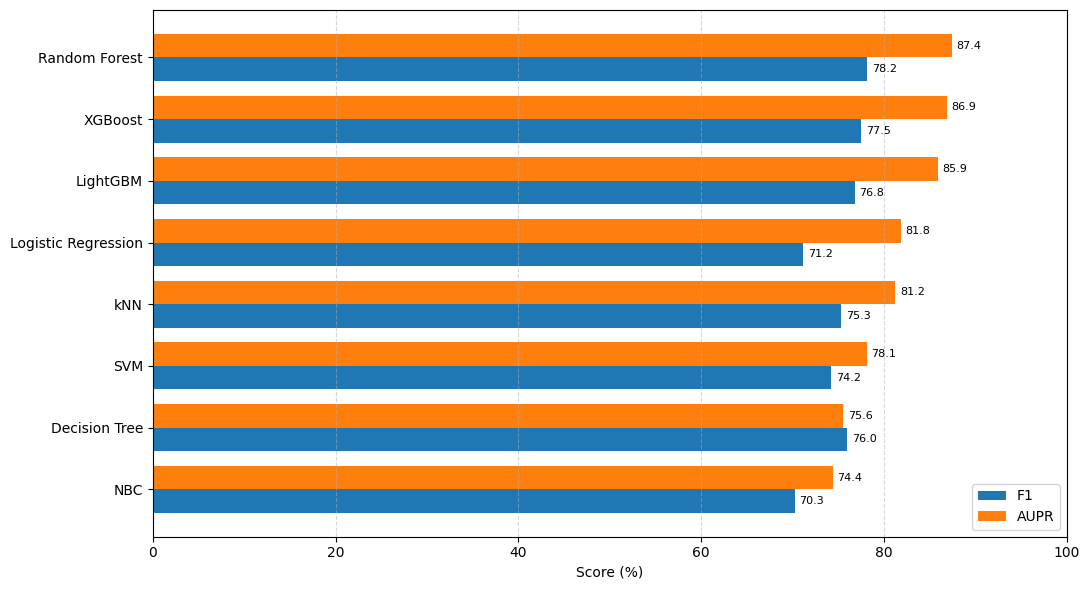

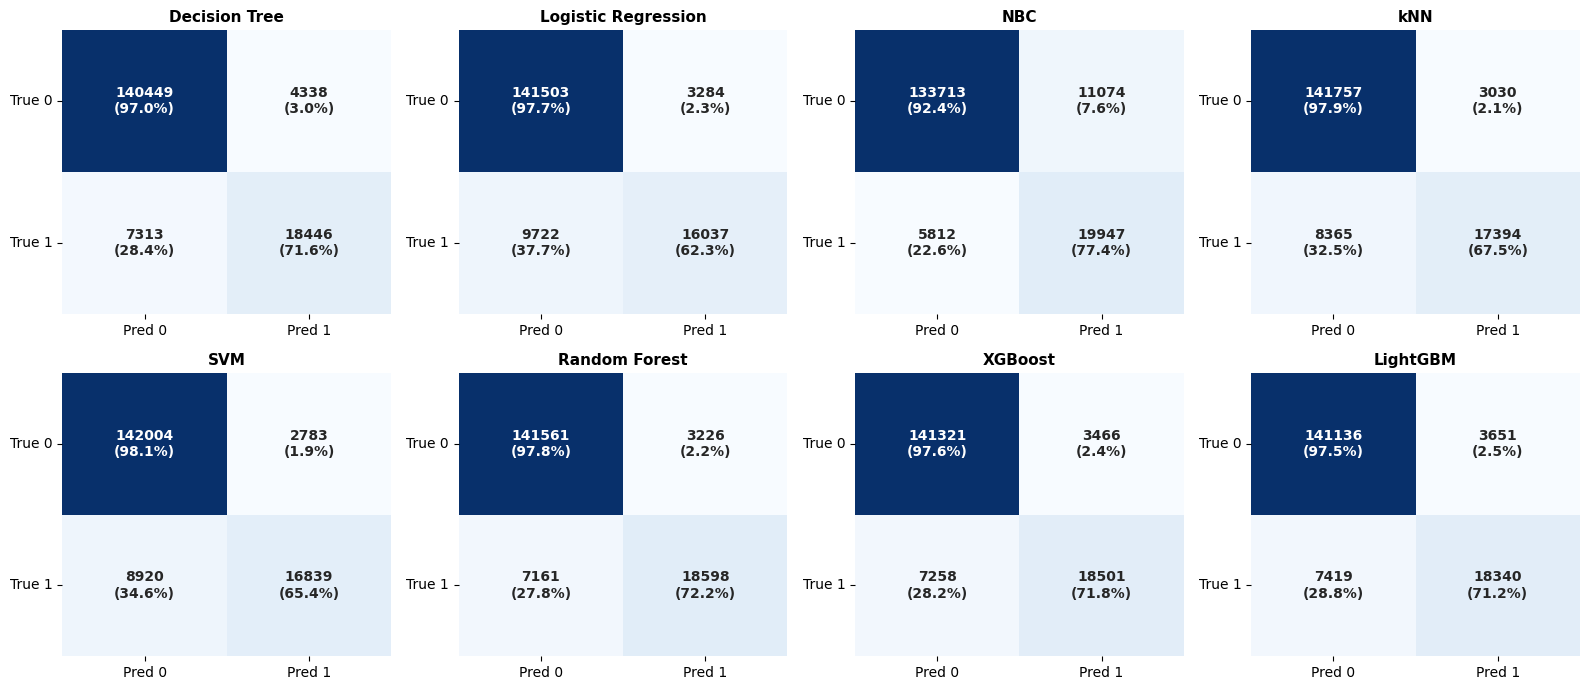

In [1]:
# ============================================================================
#  BENCHMARK 8 MÔ HÌNH ML CHO DDI — PHIÊN BẢN HOÀN THIỆN (GPU + FALLBACK)
#  - Chống lỗi predict_proba của cuML (binary trả shape (n,) thay vì (n,2))
#  - GPU cho RF/kNN/SVM (cuML), XGBoost (cuda); LightGBM tự fallback CPU nếu lỗi
#  - 5-Fold CV: báo cáo mean ± std cho TỪNG metric
#  - Kiểm định thống kê (paired t-test + Wilcoxon) giữa model tốt nhất và phần còn lại
#  - KHÔNG in ma trận nhầm lẫn từng model (gom 1 lưới tùy chọn ở cuối)
# ============================================================================
import os
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, log_loss, accuracy_score,
                             average_precision_score)

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")

# ---- Thử nạp cuML (GPU). Nếu không có, tự fallback sklearn (CPU) ----
USE_GPU = True
try:
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.neighbors import KNeighborsClassifier as cuKNN
    from cuml.svm import SVC as cuSVC
    print("[GPU] cuML sẵn sàng -> RF/kNN/SVM chạy trên GPU.")
except Exception as e:
    USE_GPU = False
    from sklearn.ensemble import RandomForestClassifier as cuRF
    from sklearn.neighbors import KNeighborsClassifier as cuKNN
    from sklearn.svm import SVC as cuSVC
    print(f"[CPU] Không nạp được cuML ({e}ops). Dùng sklearn cho RF/kNN/SVM.")


# ============================================================================
#  HÀM TIỆN ÍCH: chuẩn hóa xác suất lớp dương (xử lý mọi kiểu output)
# ============================================================================
def get_positive_proba(model, X):
    """
    Trả về mảng 1-D xác suất lớp dương, an toàn với:
      - sklearn / xgboost / lightgbm : predict_proba -> (n,2)  => lấy [:,1]
      - cuML RF (binary)             : có thể trả (n,)         => dùng trực tiếp
      - (n,1)                        : ravel
      - cupy array                   : .get() về numpy
    Trả None nếu model không hỗ trợ proba.
    """
    if not hasattr(model, "predict_proba"):
        return None
    try:
        p = model.predict_proba(X)
    except Exception:
        return None
    if hasattr(p, "get"):                 # cupy -> numpy
        try:
            p = p.get()
        except Exception:
            pass
    p = np.asarray(p, dtype=np.float64)
    if p.ndim == 1:
        return p
    if p.ndim == 2:
        if p.shape[1] == 1:
            return p.ravel()
        return p[:, 1] if p.shape[1] == 2 else p[:, -1]
    return None


# ============================================================================
#  LỚP BENCHMARK
# ============================================================================
class BenchmarkDDI:
    def __init__(self, random_state=42, n_splits=5):
        self.seed = random_state
        self.n_splits = n_splits
        self.table_data = []        # bảng tổng hợp
        self.f1_per_fold = {}       # F1 từng fold mỗi model -> dùng cho kiểm định
        self.aupr_per_fold = {}     # AUPR từng fold mỗi model
        self.avg_cms = {}           # ma trận nhầm lẫn trung bình mỗi model

    # ----- nạp dữ liệu -----
    def load_data(self, data_path):
        print(f"\n[1] Tải dữ liệu: {data_path}")
        df = pd.read_csv(data_path).fillna(0)

        # Loại MỌI cột phụ trợ có thể tồn tại (tránh lọt 'pos_split' kiểu chuỗi)
        cols_drop = ['u', 'v', 'label', 'pos_split', 'community_id',
                     'source', 'target', 'drugbank_id']
        feats = [c for c in df.columns if c not in cols_drop]

        # Ép feature về số; cột nào không ép được -> loại luôn (an toàn)
        X = df[feats].apply(pd.to_numeric, errors='coerce')
        bad_cols = X.columns[X.isna().all()].tolist()
        if bad_cols:
            print(f"   [Cảnh báo] Loại cột không phải số: {bad_cols}")
            X = X.drop(columns=bad_cols)
        self.feat_names = list(X.columns)

        self.X_raw = X.fillna(0).to_numpy(dtype=np.float32)
        self.y = df['label'].to_numpy(dtype=np.int32)

        del df, X
        gc.collect()
        pos, neg = int((self.y == 1).sum()), int((self.y == 0).sum())
        print(f"   -> X: {self.X_raw.shape} | {self.feat_names}")
        print(f"   -> Nhãn: dương={pos:,} âm={neg:,} | tỉ lệ âm:dương = {neg/max(pos,1):.2f}:1")

    # ----- danh sách model -----
    def get_models(self):
        models = []
        models.append(('Decision Tree',
                       DecisionTreeClassifier(random_state=self.seed, max_depth=15)))
        models.append(('Logistic Regression',
                       LogisticRegression(max_iter=1000, n_jobs=-1, random_state=self.seed)))
        models.append(('NBC', GaussianNB()))

        if USE_GPU:
            models.append(('kNN', cuKNN(n_neighbors=10)))
            models.append(('SVM', cuSVC(kernel='rbf', probability=True)))
            models.append(('Random Forest',
                           cuRF(n_estimators=100, max_depth=15, random_state=self.seed)))
        else:
            models.append(('kNN', cuKNN(n_neighbors=10, n_jobs=-1)))
            models.append(('SVM', cuSVC(kernel='rbf', probability=True, random_state=self.seed)))
            models.append(('Random Forest',
                           cuRF(n_estimators=100, max_depth=15, n_jobs=-1, random_state=self.seed)))

        # XGBoost: GPU nếu có
        xgb_kwargs = dict(n_estimators=100, eval_metric='logloss', random_state=self.seed)
        if USE_GPU:
            xgb_kwargs.update(tree_method='hist', device='cuda')
        models.append(('XGBoost', xgb.XGBClassifier(**xgb_kwargs)))

        # LightGBM: thử GPU, lỗi -> fallback CPU (xử lý lúc fit)
        lgb_device = 'gpu' if USE_GPU else 'cpu'
        models.append(('LightGBM',
                       lgb.LGBMClassifier(n_estimators=100, max_depth=15,
                                          device=lgb_device, random_state=self.seed,
                                          verbose=-1)))
        return dict(models)

    # ----- fit có fallback cho LightGBM GPU -----
    def _safe_fit(self, name, model, X, y):
        try:
            model.fit(X, y)
            return model, False
        except Exception as e:
            # LightGBM GPU lỗi -> dựng lại bản CPU
            if name == 'LightGBM':
                print(f"      [LightGBM] GPU lỗi ({str(e)[:50]}...). Fallback CPU.")
                model = lgb.LGBMClassifier(n_estimators=100, max_depth=15,
                                           device='cpu', random_state=self.seed, verbose=-1)
                model.fit(X, y)
                return model, True
            raise

    # ----- chạy benchmark -----
    def run(self):
        print(f"\n[2] HUẤN LUYỆN — {self.n_splits}-Fold CV\n")
        model_dict = self.get_models()
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)

        for name, model in model_dict.items():
            print(f"=== {name} ===")
            M = {'F1': [], 'Precision': [], 'Recall': [], 'Accuracy': [],
                 'Specificity': [], 'AUPR': [], 'Loss': [], 'Time': []}
            cms = []

            for fold, (tr, va) in enumerate(skf.split(self.X_raw, self.y), 1):
                t0 = time.time()
                Xtr, Xva = self.X_raw[tr], self.X_raw[va]
                ytr, yva = self.y[tr], self.y[va]

                # Chuẩn hóa TRONG fold (fit trên train, transform val) -> không leakage
                sc = StandardScaler()
                Xtr_s = sc.fit_transform(Xtr)
                Xva_s = sc.transform(Xva)

                try:
                    model, _ = self._safe_fit(name, model, Xtr_s, ytr)
                except Exception as e:
                    print(f"   -> Lỗi train {name} fold {fold}: {e}")
                    continue

                yp = model.predict(Xva_s)
                if hasattr(yp, "get"):
                    yp = yp.get()
                yp = np.asarray(yp).astype(int)

                proba = get_positive_proba(model, Xva_s)

                cm = confusion_matrix(yva, yp, labels=[0, 1])
                cms.append(cm)
                tn, fp, fn, tp = cm.ravel()

                M['F1'].append(f1_score(yva, yp, zero_division=0))
                M['Precision'].append(precision_score(yva, yp, zero_division=0))
                M['Recall'].append(recall_score(yva, yp, zero_division=0))
                M['Accuracy'].append(accuracy_score(yva, yp))
                M['Specificity'].append(tn / (tn + fp) if (tn + fp) else 0)

                if proba is not None:
                    try:
                        M['Loss'].append(log_loss(yva, proba, labels=[0, 1]))
                        M['AUPR'].append(average_precision_score(yva, proba))
                    except Exception:
                        M['Loss'].append(np.nan); M['AUPR'].append(np.nan)
                else:
                    M['Loss'].append(np.nan); M['AUPR'].append(np.nan)

                dt = time.time() - t0
                M['Time'].append(dt)
                print(f"   Fold {fold}: F1={M['F1'][-1]:.4f} "
                      f"AUPR={M['AUPR'][-1] if not np.isnan(M['AUPR'][-1]) else float('nan'):.4f} "
                      f"({dt:.1f}s)")

                del Xtr, Xva, Xtr_s, Xva_s
                gc.collect()

            # lưu để kiểm định + ma trận trung bình
            self.f1_per_fold[name] = M['F1']
            self.aupr_per_fold[name] = [v for v in M['AUPR'] if not np.isnan(v)]
            if cms:
                self.avg_cms[name] = np.mean(cms, axis=0)

            def mean_std(k, scale=100):
                vals = [v for v in M[k] if not (isinstance(v, float) and np.isnan(v))]
                if not vals:
                    return "—"
                return f"{np.mean(vals)*scale:.2f} ± {np.std(vals)*scale:.2f}"

            loss_vals = [v for v in M['Loss'] if not np.isnan(v)]
            self.table_data.append({
                'Model': name,
                'F1': mean_std('F1'),
                'AUPR': mean_std('AUPR'),
                'Precision': mean_std('Precision'),
                'Recall': mean_std('Recall'),
                'Specificity': mean_std('Specificity'),
                'Accuracy': mean_std('Accuracy'),
                'Loss': f"{np.mean(loss_vals):.4f}" if loss_vals else "—",
                'Time(s)': f"{np.mean(M['Time']):.1f}" if M['Time'] else "—",
                '_sort': np.mean(self.aupr_per_fold[name]) if self.aupr_per_fold[name] else 0,
            })
            print()

        self._print_table()

    # ----- in bảng kết quả -----
    def _print_table(self):
        print("\n[3] BẢNG TỔNG HỢP 5-FOLD CV (mean ± std, %)")
        print("=" * 70)
        if not self.table_data:
            print("Không có kết quả."); return
        df = pd.DataFrame(self.table_data).sort_values('_sort', ascending=False)
        df = df.drop(columns='_sort')
        # đưa cột quan trọng lên trước; Accuracy để cuối (theo tinh thần bài)
        order = ['Model', 'F1', 'AUPR', 'Precision', 'Recall',
                 'Specificity', 'Loss', 'Accuracy', 'Time(s)']
        df = df[[c for c in order if c in df.columns]]
        print(df.to_string(index=False))
        self.result_df = df

    # ----- kiểm định thống kê (cái bản thảo đang thiếu) -----
    def statistical_test(self, metric='f1'):
        """
        So sánh model tốt nhất với từng model còn lại bằng paired t-test + Wilcoxon
        trên giá trị per-fold. metric: 'f1' hoặc 'aupr'.
        """
        per_fold = self.f1_per_fold if metric == 'f1' else self.aupr_per_fold
        print(f"\n[4] KIỂM ĐỊNH THỐNG KÊ trên {metric.upper()} (per-fold)")
        print("=" * 70)

        # chọn model tốt nhất theo trung bình
        means = {k: np.mean(v) for k, v in per_fold.items() if len(v) == self.n_splits}
        if not means:
            print("Không đủ dữ liệu per-fold để kiểm định."); return
        best = max(means, key=means.get)
        print(f"Model tốt nhất theo {metric.upper()}: {best} "
              f"(mean = {means[best]*100:.2f}%)\n")
        print(f"{'So sánh':<32}{'Δmean(%)':>10}{'t-test p':>12}{'Wilcoxon p':>14}{'':>4}")
        print("-" * 72)

        rows = []
        a = np.array(per_fold[best])
        for name in per_fold:
            if name == best or len(per_fold[name]) != self.n_splits:
                continue
            b = np.array(per_fold[name])
            diff = a - b
            if np.allclose(diff, 0):
                print(f"{best} vs {name:<22}{'0.00':>10}{'—':>12}{'(giống hệt)':>18}")
                continue
            try:
                _, t_p = stats.ttest_rel(a, b)
            except Exception:
                t_p = np.nan
            try:
                _, w_p = stats.wilcoxon(a, b)
            except Exception:
                w_p = np.nan
            sig = "*" if (not np.isnan(t_p) and t_p < 0.05) else ""
            print(f"{best} vs {name:<22}{diff.mean()*100:>+10.2f}"
                  f"{t_p:>12.4f}{w_p:>14.4f}{sig:>4}")
            rows.append({'vs': name, 'delta_mean_%': diff.mean()*100,
                         't_p': t_p, 'wilcoxon_p': w_p})
        print("\n(*) khác biệt có ý nghĩa ở mức p < 0.05 theo paired t-test.")
        print("Lưu ý: với n=5 fold, Wilcoxon có lực kiểm định yếu; t-test thường nhạy hơn.")
        self.stat_df = pd.DataFrame(rows)

    # ----- (tùy chọn) vẽ lưới ma trận nhầm lẫn, GỌN, không spam từng cái -----
    def plot_confusion_grid(self):
        if not self.avg_cms:
            return
        n = len(self.avg_cms)
        ncol = 4
        nrow = int(np.ceil(n / ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 3.5*nrow))
        axes = np.array(axes).reshape(-1)
        for ax, (name, cm) in zip(axes, self.avg_cms.items()):
            row_sum = cm.sum(axis=1, keepdims=True)
            perc = cm / np.where(row_sum == 0, 1, row_sum) * 100
            labels = np.array([f"{int(c)}\n({p:.1f}%)"
                               for c, p in zip(cm.flatten(), perc.flatten())]).reshape(2, 2)
            sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
                        ax=ax, annot_kws={"size": 10, "weight": "bold"})
            ax.set_title(name, fontsize=11, fontweight='bold')
            ax.set_xticklabels(['Pred 0', 'Pred 1'])
            ax.set_yticklabels(['True 0', 'True 1'], rotation=0)
        for ax in axes[n:]:
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    # ----- (tùy chọn) biểu đồ F1 + AUPR -----
    def plot_summary(self):
        if not hasattr(self, 'result_df'):
            return
        df = self.result_df.copy()
        df['F1_v'] = df['F1'].str.split('±').str[0].astype(float)
        df['AUPR_v'] = df['AUPR'].str.split('±').str[0].astype(float)
        df = df.sort_values('AUPR_v', ascending=True)
        x = np.arange(len(df)); w = 0.38
        plt.figure(figsize=(11, 6))
        plt.barh(x - w/2, df['F1_v'], w, label='F1', color='#1f77b4')
        plt.barh(x + w/2, df['AUPR_v'], w, label='AUPR', color='#ff7f0e')
        plt.yticks(x, df['Model'])
        plt.xlabel('Score (%)'); plt.xlim(0, 100)
        plt.legend(); plt.grid(axis='x', linestyle='--', alpha=0.5)
        for i, (f1, au) in enumerate(zip(df['F1_v'], df['AUPR_v'])):
            plt.text(f1 + 0.5, i - w/2, f"{f1:.1f}", va='center', fontsize=8)
            plt.text(au + 0.5, i + w/2, f"{au:.1f}", va='center', fontsize=8)
        plt.tight_layout()
        plt.show()


# ============================================================================
#  CHẠY
# ============================================================================
if __name__ == "__main__":

    DATA_FILE = "/kaggle/input/datasets/vungocthien/data-traintest/train_data.csv"

    if not os.path.exists(DATA_FILE):
        print(f"[LỖI] Không thấy {DATA_FILE}. Kiểm tra lại đường dẫn.")
    else:
        bench = BenchmarkDDI(random_state=42, n_splits=5)
        bench.load_data(DATA_FILE)
        bench.run()
        bench.statistical_test(metric='f1')     # kiểm định trên F1
        bench.statistical_test(metric='aupr')   # và trên AUPR
        bench.plot_summary()                    # biểu đồ F1/AUPR
        bench.plot_confusion_grid()             # lưới CM (1 hình, không spam)

[GPU] cuML sẵn sàng.

[1] Tải Train & Test...
   -> Train: (852738, 12) | dương=128,799 âm=723,939 (âm:dương=5.62:1)
   -> Test : (439290, 12) | dương=66,351 âm=372,939 (âm:dương=5.62:1)
   -> Feature (12): ['cn', 'rai', 'jc', 'aai', 'pa', 'ccn', 'cra', 'wic', 'sim_atc', 'sim_mesh', 'sim_ade', 'sim_chemical']
   -> Chế độ multi-run: 'bootstrap'

[2] HUẤN LUYỆN — lặp 5 lần (mode=bootstrap), đánh giá trên TEST holdout cố định

=== NBC ===

=== KNN ===

=== SVM ===

=== RF ===

=== DT ===

=== LR ===

=== XGB ===

=== LG ===


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.




[3] BẢNG TỔNG HỢP 5 LẦN CHẠY (mean ± std, %) — mode=bootstrap, trên TEST holdout
Model           F1         AUPR    Precision       Recall  Specificity   Loss     Accuracy Time(s)
   RF 78.26 ± 0.02 87.44 ± 0.02 85.32 ± 0.15 72.27 ± 0.08 97.79 ± 0.03 0.1595 93.93 ± 0.01     6.8
  XGB 77.49 ± 0.09 86.75 ± 0.03 84.19 ± 0.16 71.78 ± 0.23 97.60 ± 0.03 0.1637 93.70 ± 0.02     2.2
   LG 76.71 ± 0.03 85.24 ± 0.36 83.37 ± 0.19 71.04 ± 0.12 97.48 ± 0.04 0.1734 93.49 ± 0.02     8.2
   LR 71.44 ± 0.18 82.16 ± 0.18 83.27 ± 0.20 62.55 ± 0.17 97.76 ± 0.03 0.2001 92.44 ± 0.05     4.0
  KNN 74.37 ± 0.07 79.05 ± 0.02 83.18 ± 0.10 67.25 ± 0.11 97.58 ± 0.02 0.7096 93.00 ± 0.02    22.4
  SVM 74.43 ± 0.01 78.77 ± 0.07 86.02 ± 0.06 65.59 ± 0.05 98.10 ± 0.01 0.2170 93.19 ± 0.00   471.2
   DT 75.62 ± 0.21 74.53 ± 0.34 80.22 ± 0.28 71.51 ± 0.39 96.86 ± 0.06 0.6407 93.03 ± 0.05    11.2
  NBC 70.53 ± 0.02 74.52 ± 0.07 64.52 ± 0.04 77.78 ± 0.06 92.39 ± 0.02 1.2868 90.18 ± 0.01     1.2


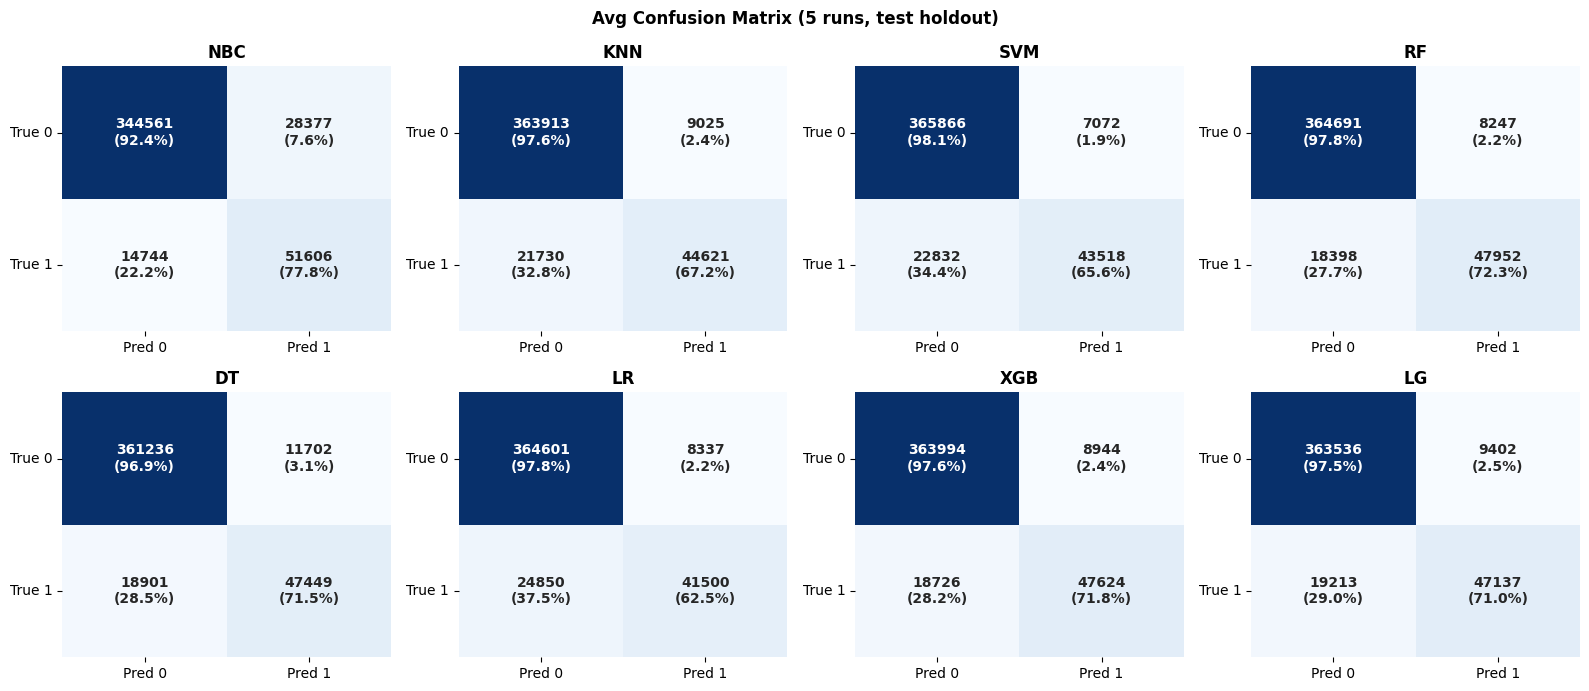

In [2]:
# ============================================================================
#  BENCHMARK DDI — MULTI-RUN ĐÁNH GIÁ TRÊN TEST HOLDOUT (v3)
#  Ý nghĩa: lặp N lần, MỖI lần xáo trộn/bootstrap lại TRAIN theo seed,
#           train rồi đánh giá trên CÙNG test holdout cố định.
#  -> Đo VARIANCE thật của hiệu năng (kể cả model deterministic như NBC/kNN/SVM/LR
#      cũng dao động, vì tập train mỗi lần khác nhau).
#  Khác biệt với bản cũ: bản cũ chỉ đổi random_state của model (dữ liệu cố định)
#      nên NBC/kNN/SVM/LR cho kết quả y hệt -> std=0 vô nghĩa.
#
#  Vẫn giữ: chống lỗi cuML proba (n,), fallback LightGBM CPU, loại cột phụ trợ,
#           mean ± std, KHÔNG spam confusion matrix.
# ============================================================================
import os
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, log_loss, accuracy_score,
                             average_precision_score)

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")

USE_GPU = True
try:
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.neighbors import KNeighborsClassifier as cuKNN
    from cuml.svm import SVC as cuSVC
    print("[GPU] cuML sẵn sàng.")
except Exception as e:
    USE_GPU = False
    from sklearn.ensemble import RandomForestClassifier as cuRF
    from sklearn.neighbors import KNeighborsClassifier as cuKNN
    from sklearn.svm import SVC as cuSVC
    print(f"[CPU] Không có cuML ({type(e).__name__}) -> sklearn fallback.")


# ---------- tiện ích proba/label (chống lỗi cuML) ----------
def get_positive_proba(model, X):
    if not hasattr(model, "predict_proba"):
        return None
    try:
        p = model.predict_proba(X)
    except Exception:
        return None
    if hasattr(p, "get"):
        try: p = p.get()
        except Exception: pass
    p = np.asarray(p, dtype=np.float64)
    if p.ndim == 1:
        return p
    if p.ndim == 2:
        if p.shape[1] == 1: return p.ravel()
        return p[:, 1] if p.shape[1] == 2 else p[:, -1]
    return None

def _to_numpy_labels(y):
    if hasattr(y, "get"):
        try: y = y.get()
        except Exception: pass
    return np.asarray(y).astype(int)


class BenchmarkMultiRun:
    """
    mode='bootstrap' : mỗi lần lấy mẫu bootstrap (có hoàn lại) từ train -> variance thật
    mode='shuffle'   : mỗi lần xáo trộn + đổi seed model (giữ nguyên kích thước train)
    """
    def __init__(self, seeds=(7, 99, 123, 999, 2024), mode='bootstrap'):
        self.seeds = list(seeds)
        self.mode = mode
        self.table = []
        self.f1_runs = {}     # F1 mỗi lần chạy -> để tính std + (tùy chọn) kiểm định
        self.aupr_runs = {}
        self.avg_cms = {}

    # ---------- nạp dữ liệu ----------
    def _read_xy(self, path):
        df = pd.read_csv(path).fillna(0)
        cols_drop = ['u', 'v', 'label', 'pos_split', 'community_id',
                     'source', 'target', 'drugbank_id']
        feats = [c for c in df.columns if c not in cols_drop]
        X = df[feats].apply(pd.to_numeric, errors='coerce')
        bad = X.columns[X.isna().all()].tolist()
        if bad:
            print(f"   [Cảnh báo] Loại cột không phải số: {bad}")
            X = X.drop(columns=bad)
        self.feat_names = list(X.columns)
        return X.fillna(0).to_numpy(np.float32), df['label'].to_numpy(np.int32)

    def load_data(self, train_path, test_path):
        print(f"\n[1] Tải Train & Test...")
        self.X_train_raw, self.y_train = self._read_xy(train_path)
        self.X_test_raw, self.y_test = self._read_xy(test_path)
        p, n = int((self.y_train == 1).sum()), int((self.y_train == 0).sum())
        pt, nt = int((self.y_test == 1).sum()), int((self.y_test == 0).sum())
        print(f"   -> Train: {self.X_train_raw.shape} | dương={p:,} âm={n:,} "
              f"(âm:dương={n/max(p,1):.2f}:1)")
        print(f"   -> Test : {self.X_test_raw.shape} | dương={pt:,} âm={nt:,} "
              f"(âm:dương={nt/max(pt,1):.2f}:1)")
        print(f"   -> Feature ({len(self.feat_names)}): {self.feat_names}")
        print(f"   -> Chế độ multi-run: '{self.mode}'")

    # ---------- model (deterministic vs stochastic được đánh dấu) ----------
    def get_models(self, seed):
        m = []
        m.append(('NBC', GaussianNB()))
        if USE_GPU:
            m.append(('KNN', cuKNN(n_neighbors=10)))
            m.append(('SVM', cuSVC(kernel='rbf', probability=True)))
            m.append(('RF', cuRF(n_estimators=100, max_depth=15, random_state=seed)))
        else:
            m.append(('KNN', cuKNN(n_neighbors=10, n_jobs=-1)))
            m.append(('SVM', cuSVC(kernel='rbf', probability=True, random_state=seed)))
            m.append(('RF', cuRF(n_estimators=100, max_depth=15, n_jobs=-1, random_state=seed)))
        m.append(('DT', DecisionTreeClassifier(random_state=seed, max_depth=15)))
        m.append(('LR', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=seed)))
        xgb_kwargs = dict(n_estimators=100, eval_metric='logloss', random_state=seed)
        if USE_GPU:
            xgb_kwargs.update(tree_method='hist', device='cuda')
        m.append(('XGB', xgb.XGBClassifier(**xgb_kwargs)))
        m.append(('LG', lgb.LGBMClassifier(n_estimators=100, max_depth=15,
                                           device=('gpu' if USE_GPU else 'cpu'),
                                           random_state=seed, verbose=-1)))
        return dict(m)

    def _safe_fit(self, name, model, X, y):
        try:
            model.fit(X, y); return model
        except Exception as e:
            if name == 'LG':
                print(f"      [LG] GPU lỗi ({str(e)[:40]}...). Fallback CPU.")
                model = lgb.LGBMClassifier(n_estimators=100, max_depth=15,
                                           device='cpu', random_state=42, verbose=-1)
                model.fit(X, y); return model
            raise

    # ---------- tạo tập train cho mỗi lần chạy ----------
    def _make_train(self, seed):
        """
        bootstrap: lấy mẫu có hoàn lại cùng kích thước (variance thật, mọi model dao động)
        shuffle  : xáo trộn thứ tự (chủ yếu ảnh hưởng model phụ thuộc thứ tự + seed model)
        """
        n = len(self.y_train)
        if self.mode == 'bootstrap':
            idx = resample(np.arange(n), replace=True, n_samples=n, random_state=seed,
                           stratify=self.y_train)  # giữ tỉ lệ lớp
        else:  # shuffle
            rng = np.random.RandomState(seed)
            idx = rng.permutation(n)
        return self.X_train_raw[idx], self.y_train[idx]

    # ---------- chạy ----------
    def run(self):
        print(f"\n[2] HUẤN LUYỆN — lặp {len(self.seeds)} lần (mode={self.mode}), "
              f"đánh giá trên TEST holdout cố định\n")
        names = list(self.get_models(seed=0).keys())

        for name in names:
            print(f"=== {name} ===")
            M = {k: [] for k in ['F1', 'Precision', 'Recall', 'Accuracy',
                                  'Specificity', 'AUPR', 'Loss', 'Time']}
            cms = []
            for seed in self.seeds:
                t0 = time.time()
                Xtr_raw, ytr = self._make_train(seed)

                # Scaler fit TRONG mỗi lần chạy (trên train của lần đó), transform test
                sc = StandardScaler()
                Xtr = sc.fit_transform(Xtr_raw)
                Xte = sc.transform(self.X_test_raw)

                model = self.get_models(seed)[name]
                try:
                    model = self._safe_fit(name, model, Xtr, ytr)
                except Exception as e:
                    print(f"   seed {seed} lỗi: {e}"); continue

                yp = _to_numpy_labels(model.predict(Xte))
                proba = get_positive_proba(model, Xte)

                cm = confusion_matrix(self.y_test, yp, labels=[0, 1])
                cms.append(cm)
                tn, fp, fn, tp = cm.ravel()
                M['F1'].append(f1_score(self.y_test, yp, zero_division=0))
                M['Precision'].append(precision_score(self.y_test, yp, zero_division=0))
                M['Recall'].append(recall_score(self.y_test, yp, zero_division=0))
                M['Accuracy'].append(accuracy_score(self.y_test, yp))
                M['Specificity'].append(tn/(tn+fp) if (tn+fp) else 0)
                if proba is not None:
                    try:
                        M['Loss'].append(log_loss(self.y_test, proba, labels=[0, 1]))
                        M['AUPR'].append(average_precision_score(self.y_test, proba))
                    except Exception:
                        M['Loss'].append(np.nan); M['AUPR'].append(np.nan)
                else:
                    M['Loss'].append(np.nan); M['AUPR'].append(np.nan)
                M['Time'].append(time.time()-t0)
                del Xtr_raw, Xtr, Xte; gc.collect()

            if cms:
                self.avg_cms[name] = np.mean(cms, axis=0)
            self.f1_runs[name] = M['F1']
            self.aupr_runs[name] = [v for v in M['AUPR'] if not np.isnan(v)]

            def ms(k):
                vals = [v for v in M[k] if not (isinstance(v, float) and np.isnan(v))]
                return f"{np.mean(vals)*100:.2f} ± {np.std(vals)*100:.2f}" if vals else "—"
            loss = [v for v in M['Loss'] if not np.isnan(v)]
            self.table.append({
                'Model': name, 'F1': ms('F1'), 'AUPR': ms('AUPR'),
                'Precision': ms('Precision'), 'Recall': ms('Recall'),
                'Specificity': ms('Specificity'), 'Accuracy': ms('Accuracy'),
                'Loss': f"{np.mean(loss):.4f}" if loss else "—",
                'Time(s)': f"{np.mean(M['Time']):.1f}" if M['Time'] else "—",
                '_sort': np.mean(self.aupr_runs[name]) if self.aupr_runs[name] else 0,
            })
            # cảnh báo nếu std≈0 (model deterministic + mode shuffle)
            f1_std = np.std(M['F1'])*100 if M['F1'] else 0
            if self.mode == 'shuffle' and f1_std < 1e-6 and name in ('NBC', 'KNN', 'SVM', 'LR'):
                print(f"   [Lưu ý] {name} là model xác định -> std≈0 ở mode 'shuffle'. "
                      f"Dùng mode='bootstrap' để có variance thật.")
            print()
        self._print_table()

    def _print_table(self):
        print(f"\n[3] BẢNG TỔNG HỢP {len(self.seeds)} LẦN CHẠY (mean ± std, %) — "
              f"mode={self.mode}, trên TEST holdout")
        print("=" * 72)
        df = pd.DataFrame(self.table).sort_values('_sort', ascending=False).drop(columns='_sort')
        order = ['Model', 'F1', 'AUPR', 'Precision', 'Recall', 'Specificity', 'Loss', 'Accuracy', 'Time(s)']
        df = df[[c for c in order if c in df.columns]]
        print(df.to_string(index=False))
        self.result_df = df

    def plot_confusion_grid(self):
        if not self.avg_cms:
            return
        n = len(self.avg_cms); ncol = 4; nrow = int(np.ceil(n/ncol))
        fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 3.5*nrow))
        axes = np.array(axes).reshape(-1)
        for ax, (name, cm) in zip(axes, self.avg_cms.items()):
            rs = cm.sum(1, keepdims=True); perc = cm/np.where(rs == 0, 1, rs)*100
            lab = np.array([f"{int(c)}\n({p:.1f}%)" for c, p in
                            zip(cm.flatten(), perc.flatten())]).reshape(2, 2)
            sns.heatmap(cm, annot=lab, fmt='', cmap='Blues', cbar=False, ax=ax,
                        annot_kws={"size": 10, "weight": "bold"})
            ax.set_title(name, fontweight='bold')
            ax.set_xticklabels(['Pred 0', 'Pred 1']); ax.set_yticklabels(['True 0', 'True 1'], rotation=0)
        for ax in axes[n:]: ax.axis('off')
        plt.suptitle(f'Avg Confusion Matrix ({len(self.seeds)} runs, test holdout)', fontweight='bold')
        plt.tight_layout(); plt.show()


if __name__ == "__main__":
    TRAIN_FILE = "/kaggle/input/datasets/vungocthien/data-traintest/train_data.csv"
    TEST_FILE  = "/kaggle/input/datasets/vungocthien/data-traintest/test_data.csv"

    if os.path.exists(TRAIN_FILE) and os.path.exists(TEST_FILE):
        # mode='bootstrap' -> đo variance THẬT (khuyến nghị, mọi model đều dao động)
        bench = BenchmarkMultiRun(seeds=(7, 99, 123, 999, 2024), mode='bootstrap')
        bench.load_data(TRAIN_FILE, TEST_FILE)
        bench.run()
        bench.plot_confusion_grid()
    else:
        print("Lỗi: Không tìm thấy file Train/Test.")


---
# Đánh giá độ quan trọng của các đặc trưng

[1] Tải dữ liệu...
   -> Train: (852738, 12) | Test: (439290, 12)
   -> 12 đặc trưng: ['cn', 'rai', 'jc', 'aai', 'pa', 'ccn', 'cra', 'wic', 'atc', 'mesh', 'ade', 'chem']

[2] LEAVE-ONE-OUT — bỏ từng đặc trưng, đo trên TEST holdout
   Baseline (đủ 12 đặc trưng): F1=78.46  AUPR=87.64

   ΔF1 < 0: bỏ đi thì TỆ hơn -> đặc trưng QUAN TRỌNG
   ΔF1 > 0: bỏ đi thì TỐT hơn -> đặc trưng GÂY NHIỄU

Bỏ đặc trưng    F1   ΔF1  AUPR ΔAUPR
         rai 77.61 -0.85 86.90 -0.74
          jc 77.79 -0.68 87.03 -0.62
          pa 77.94 -0.52 87.13 -0.51
        mesh 78.16 -0.30 87.43 -0.21
         wic 78.34 -0.12 87.58 -0.06
        chem 78.34 -0.12 87.64 -0.00
         ccn 78.39 -0.07 87.59 -0.05
         cra 78.42 -0.04 87.57 -0.07
         atc 78.43 -0.03 87.60 -0.04
         ade 78.44 -0.02 87.67 +0.03
          cn 78.45 -0.01 87.64 +0.00
         aai 78.47 +0.01 87.68 +0.04

[3] SHAP CUMULATIVE — xếp hạng bằng SHAP (trên TRAIN), thêm dần
   Xếp hạng |SHAP| (giảm dần, tính trên TRAIN):
      rai     :

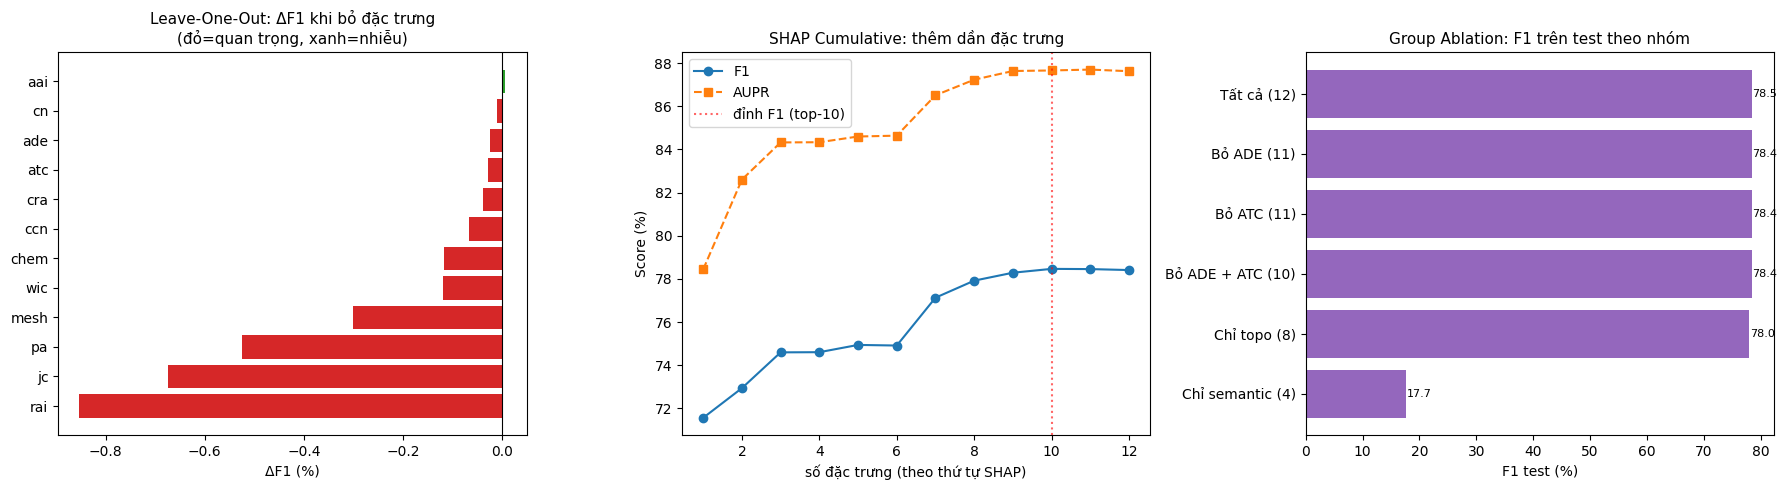

In [1]:
# ============================================================================
#  ABLATION STUDY — ĐÁNH GIÁ ĐỘ QUAN TRỌNG ĐẶC TRƯNG CHO DDI
#  Ý tưởng: "nhiều đặc trưng KHÔNG đồng nghĩa tốt hơn" — đặc trưng nhiễu có thể
#           làm giảm hiệu năng. Ta bật/tắt đặc trưng để chứng minh điều đó.
#
#  NGUYÊN TẮC CHỐNG LEAKAGE (quan trọng):
#    - Việc QUYẾT ĐỊNH bỏ đặc trưng nào dựa trên SHAP/CV trên TRAIN.
#    - TEST holdout chỉ dùng để XÁC NHẬN một lần cuối, KHÔNG dùng để chọn.
#    - Nếu thử nhiều tổ hợp rồi chọn tổ hợp tốt nhất TRÊN TEST -> leakage mới.
#
#  Ba phương pháp bổ trợ nhau:
#    (1) Leave-One-Out : bỏ TỪNG đặc trưng -> đặc trưng nào quan trọng/gây hại
#    (2) SHAP Cumulative: xếp hạng SHAP rồi thêm dần đặc trưng -> tìm điểm bão hòa
#    (3) Group Ablation : bật/tắt theo NHÓM (chỉ topo / chỉ semantic / bỏ ADE+ATC...)
# ============================================================================
import os
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score

warnings.filterwarnings("ignore")

# Model dùng cho ablation: mặc định Random Forest (model mạnh nhất trong bài).
# Dùng sklearn để chạy SHAP ổn định; nếu có cuML có thể đổi nhưng SHAP hợp sklearn hơn.
from sklearn.ensemble import RandomForestClassifier

# SHAP (nếu không có thì phần SHAP cumulative sẽ báo và bỏ qua)
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("[Lưu ý] Chưa cài 'shap' -> phương pháp SHAP cumulative sẽ bị bỏ qua. "
          "Cài bằng: pip install shap")


# ---------- nhóm đặc trưng (đúng theo bản thảo) ----------
TOPO_FEATS = ['cn', 'jc', 'aai', 'pa', 'rai', 'ccn', 'cra', 'wic']
SEMANTIC_FEATS = ['sim_atc', 'sim_chemical', 'sim_mesh', 'sim_ade']
# tên hiển thị gọn
DISPLAY = {'sim_atc': 'atc', 'sim_chemical': 'chem', 'sim_mesh': 'mesh', 'sim_ade': 'ade'}


def _disp(c):
    return DISPLAY.get(c, c)


class FeatureAblation:
    def __init__(self, train_path, test_path, model_factory=None,
                 random_state=42, n_splits=5):
        self.seed = random_state
        self.n_splits = n_splits
        self.model_factory = model_factory or (
            lambda: RandomForestClassifier(n_estimators=100, max_depth=15,
                                           random_state=self.seed, n_jobs=-1))
        self._load(train_path, test_path)

    # ---------- nạp dữ liệu ----------
    def _read(self, path):
        df = pd.read_csv(path).fillna(0)
        drop = ['u', 'v', 'label', 'pos_split', 'community_id',
                'source', 'target', 'drugbank_id']
        feats = [c for c in df.columns if c not in drop]
        X = df[feats].apply(pd.to_numeric, errors='coerce')
        bad = X.columns[X.isna().all()].tolist()
        if bad:
            X = X.drop(columns=bad)
        return X.fillna(0), df['label'].to_numpy(np.int32)

    def _load(self, train_path, test_path):
        print("[1] Tải dữ liệu...")
        self.Xtr_df, self.ytr = self._read(train_path)
        self.Xte_df, self.yte = self._read(test_path)
        self.all_feats = list(self.Xtr_df.columns)
        print(f"   -> Train: {self.Xtr_df.shape} | Test: {self.Xte_df.shape}")
        print(f"   -> {len(self.all_feats)} đặc trưng: {[_disp(c) for c in self.all_feats]}")

    # ---------- hàm lõi: đánh giá 1 tập đặc trưng ----------
    def _eval_on_test(self, feats):
        """Train trên train (toàn bộ), đánh giá 1 lần trên test. Trả (F1, AUPR)."""
        Xtr = self.Xtr_df[feats].to_numpy(np.float32)
        Xte = self.Xte_df[feats].to_numpy(np.float32)
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr)
        Xte_s = sc.transform(Xte)
        m = self.model_factory()
        m.fit(Xtr_s, self.ytr)
        yp = m.predict(Xte_s)
        proba = m.predict_proba(Xte_s)
        proba = proba[:, 1] if proba.ndim == 2 and proba.shape[1] == 2 else np.ravel(proba)
        return (f1_score(self.yte, yp, zero_division=0),
                average_precision_score(self.yte, proba))

    def _eval_cv(self, feats):
        """5-Fold CV trên TRAIN cho 1 tập đặc trưng. Trả (mean_F1, std_F1)."""
        X = self.Xtr_df[feats].to_numpy(np.float32)
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.seed)
        f1s = []
        for tr, va in skf.split(X, self.ytr):
            sc = StandardScaler()
            Xtr_s = sc.fit_transform(X[tr])
            Xva_s = sc.transform(X[va])
            m = self.model_factory()
            m.fit(Xtr_s, self.ytr[tr])
            yp = m.predict(Xva_s)
            f1s.append(f1_score(self.ytr[va], yp, zero_division=0))
        return np.mean(f1s), np.std(f1s)

    # ========================================================================
    #  (1) LEAVE-ONE-OUT: bỏ TỪNG đặc trưng
    # ========================================================================
    def leave_one_out(self):
        print("\n[2] LEAVE-ONE-OUT — bỏ từng đặc trưng, đo trên TEST holdout")
        print("=" * 68)
        base_f1, base_aupr = self._eval_on_test(self.all_feats)
        print(f"   Baseline (đủ {len(self.all_feats)} đặc trưng): "
              f"F1={base_f1*100:.2f}  AUPR={base_aupr*100:.2f}\n")

        rows = []
        for f in self.all_feats:
            subset = [c for c in self.all_feats if c != f]
            f1, aupr = self._eval_on_test(subset)
            rows.append({
                'Bỏ đặc trưng': _disp(f),
                'F1': f1*100, 'ΔF1': (f1-base_f1)*100,
                'AUPR': aupr*100, 'ΔAUPR': (aupr-base_aupr)*100,
            })
        df = pd.DataFrame(rows).sort_values('ΔF1')  # ΔF1 âm nhất ở trên = bỏ gây hại nhất
        # diễn giải:
        #   ΔF1 < 0 (bỏ -> tệ đi)  => đặc trưng QUAN TRỌNG (giữ)
        #   ΔF1 > 0 (bỏ -> tốt lên) => đặc trưng GÂY NHIỄU (nên bỏ)
        print("   ΔF1 < 0: bỏ đi thì TỆ hơn -> đặc trưng QUAN TRỌNG")
        print("   ΔF1 > 0: bỏ đi thì TỐT hơn -> đặc trưng GÂY NHIỄU\n")
        disp = df.copy()
        for c in ['F1', 'ΔF1', 'AUPR', 'ΔAUPR']:
            disp[c] = disp[c].map(lambda x: f"{x:+.2f}" if c.startswith('Δ') else f"{x:.2f}")
        print(disp.to_string(index=False))
        self.loo_df = df
        self.loo_baseline = (base_f1, base_aupr)
        return df

    # ========================================================================
    #  (2) SHAP CUMULATIVE: xếp hạng SHAP trên TRAIN, thêm dần đặc trưng
    # ========================================================================
    def shap_cumulative(self, shap_sample=2000):
        if not HAS_SHAP:
            print("\n[3] SHAP cumulative: BỎ QUA (chưa cài shap).")
            return None
        print("\n[3] SHAP CUMULATIVE — xếp hạng bằng SHAP (trên TRAIN), thêm dần")
        print("=" * 68)

        # --- xếp hạng đặc trưng bằng SHAP, TÍNH TRÊN TRAIN (không đụng test) ---
        Xtr = self.Xtr_df[self.all_feats].to_numpy(np.float32)
        sc = StandardScaler()
        Xtr_s = sc.fit_transform(Xtr)
        m = self.model_factory()
        m.fit(Xtr_s, self.ytr)

        # lấy mẫu để SHAP chạy nhanh
        n = min(shap_sample, len(Xtr_s))
        idx = np.random.RandomState(self.seed).choice(len(Xtr_s), n, replace=False)
        explainer = shap.TreeExplainer(m)
        sv = explainer.shap_values(Xtr_s[idx])
        # shap cho binary có thể trả list[2] hoặc array 3D -> lấy lớp dương
        if isinstance(sv, list):
            sv = sv[1]
        sv = np.asarray(sv)
        if sv.ndim == 3:           # (n, feat, class)
            sv = sv[:, :, 1]
        importance = np.abs(sv).mean(axis=0)   # |SHAP| trung bình mỗi đặc trưng

        ranking = sorted(zip(self.all_feats, importance), key=lambda x: -x[1])
        print("   Xếp hạng |SHAP| (giảm dần, tính trên TRAIN):")
        for f, imp in ranking:
            print(f"      {_disp(f):8s}: {imp:.4f}")
        ranked_feats = [f for f, _ in ranking]

        # --- thêm dần theo thứ tự SHAP, đo F1 trên TEST ---
        print("\n   Thêm dần đặc trưng theo thứ tự SHAP -> đo trên TEST:")
        rows = []
        for k in range(1, len(ranked_feats)+1):
            subset = ranked_feats[:k]
            f1, aupr = self._eval_on_test(subset)
            rows.append({'k': k, 'Thêm': _disp(ranked_feats[k-1]),
                         'F1': f1*100, 'AUPR': aupr*100})
            print(f"      top-{k:2d} ({_disp(ranked_feats[k-1]):8s}): "
                  f"F1={f1*100:.2f}  AUPR={aupr*100:.2f}")
        df = pd.DataFrame(rows)
        best_k = df.loc[df['F1'].idxmax(), 'k']
        print(f"\n   -> F1 đạt đỉnh ở top-{int(best_k)} đặc trưng "
              f"(thêm nữa KHÔNG cải thiện -> minh chứng 'nhiều ≠ tốt').")
        self.shap_cum_df = df
        self.shap_ranking = ranked_feats
        return df

    # ========================================================================
    #  (3) GROUP ABLATION: bật/tắt theo NHÓM (đúng tinh thần bản thảo)
    # ========================================================================
    def group_ablation(self):
        print("\n[4] GROUP ABLATION — bật/tắt theo nhóm đặc trưng (trên TEST)")
        print("=" * 68)
        topo = [c for c in self.all_feats if c in TOPO_FEATS]
        sem = [c for c in self.all_feats if c in SEMANTIC_FEATS]

        configs = {
            'Tất cả (12)': self.all_feats,
            'Chỉ topo (8)': topo,
            'Chỉ semantic (4)': sem,
            'Bỏ ADE + ATC (10)': [c for c in self.all_feats
                                   if c not in ('sim_ade', 'sim_atc')],
            'Bỏ ADE (11)': [c for c in self.all_feats if c != 'sim_ade'],
            'Bỏ ATC (11)': [c for c in self.all_feats if c != 'sim_atc'],
        }
        rows = []
        for name, feats in configs.items():
            if not feats:
                continue
            f1_cv, std_cv = self._eval_cv(feats)
            f1_te, aupr_te = self._eval_on_test(feats)
            rows.append({
                'Cấu hình': name, '#feat': len(feats),
                'F1_CV(train)': f"{f1_cv*100:.2f} ± {std_cv*100:.2f}",
                'F1_test': f1_te*100, 'AUPR_test': aupr_te*100,
            })
        df = pd.DataFrame(rows)
        disp = df.copy()
        disp['F1_test'] = disp['F1_test'].map(lambda x: f"{x:.2f}")
        disp['AUPR_test'] = disp['AUPR_test'].map(lambda x: f"{x:.2f}")
        print(disp.to_string(index=False))
        print("\n   So sánh 'Tất cả (12)' với 'Bỏ ADE + ATC (10)':")
        print("   nếu bỏ 2 đặc trưng mà F1 KHÔNG giảm (thậm chí tăng) -> xác nhận")
        print("   chúng là nhiễu, củng cố lập luận 'nhiều đặc trưng ≠ tốt hơn'.")
        self.group_df = df
        return df

    # ---------- biểu đồ tổng hợp ----------
    def plot_all(self):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # (1) Leave-one-out
        if hasattr(self, 'loo_df'):
            d = self.loo_df
            colors = ['#d62728' if v < 0 else '#2ca02c' for v in d['ΔF1']]
            axes[0].barh(d['Bỏ đặc trưng'], d['ΔF1'], color=colors)
            axes[0].axvline(0, color='k', lw=0.8)
            axes[0].set_title('Leave-One-Out: ΔF1 khi bỏ đặc trưng\n'
                              '(đỏ=quan trọng, xanh=nhiễu)', fontsize=11)
            axes[0].set_xlabel('ΔF1 (%)')

        # (2) SHAP cumulative
        if hasattr(self, 'shap_cum_df'):
            d = self.shap_cum_df
            axes[1].plot(d['k'], d['F1'], 'o-', color='#1f77b4', label='F1')
            axes[1].plot(d['k'], d['AUPR'], 's--', color='#ff7f0e', label='AUPR')
            best_k = d.loc[d['F1'].idxmax(), 'k']
            axes[1].axvline(best_k, color='red', ls=':', alpha=0.6,
                            label=f'đỉnh F1 (top-{int(best_k)})')
            axes[1].set_title('SHAP Cumulative: thêm dần đặc trưng', fontsize=11)
            axes[1].set_xlabel('số đặc trưng (theo thứ tự SHAP)')
            axes[1].set_ylabel('Score (%)'); axes[1].legend()
        else:
            axes[1].text(0.5, 0.5, 'SHAP chưa khả dụng', ha='center', va='center')
            axes[1].axis('off')

        # (3) Group ablation
        if hasattr(self, 'group_df'):
            d = self.group_df.sort_values('F1_test')
            axes[2].barh(d['Cấu hình'], d['F1_test'], color='#9467bd')
            axes[2].set_title('Group Ablation: F1 trên test theo nhóm', fontsize=11)
            axes[2].set_xlabel('F1 test (%)')
            for i, v in enumerate(d['F1_test']):
                axes[2].text(v + 0.1, i, f"{v:.1f}", va='center', fontsize=8)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    TRAIN_FILE = "/kaggle/input/datasets/vungocthien/data-traintest/train_data.csv"
    TEST_FILE = "/kaggle/input/datasets/vungocthien/data-traintest/test_data.csv"

    if os.path.exists(TRAIN_FILE) and os.path.exists(TEST_FILE):
        ab = FeatureAblation(TRAIN_FILE, TEST_FILE, random_state=42, n_splits=5)
        ab.leave_one_out()      # (1) bỏ từng đặc trưng
        ab.shap_cumulative()    # (2) xếp hạng SHAP + thêm dần
        ab.group_ablation()     # (3) bật/tắt theo nhóm
        ab.plot_all()           # biểu đồ tổng hợp
    else:
        print("Lỗi: Không tìm thấy file train/test.")

In [3]:
# ============================================================================
#  ENSEMBLE CHO DDI — BẢN TỐI ƯU GPU (cuML drop-in, gọn & nhanh)
#  - SVM/RF/LR chạy GPU qua cuML -> nhanh tới ~35-100x so với CPU
#  - cuML estimators drop-in thẳng vào Stacking/Voting của sklearn (đã được hỗ trợ)
#  - Giữ cv=5 (chống leakage) | so sánh base đơn lẻ vs Hard/Soft/Stacking
#  - Hard Voting không có proba -> AUPR để "—"
# ============================================================================
import os, gc, time, warnings
import numpy as np, pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, log_loss, average_precision_score)
warnings.filterwarnings("ignore")

# ---- base learners GPU (cuML) nếu có; không thì sklearn CPU ----
try:
    from cuml.ensemble import RandomForestClassifier as RF
    from cuml.svm import SVC
    from cuml.linear_model import LogisticRegression as LR
    GPU = True
    print("[GPU] Dùng cuML cho RF/SVM/LR (nhanh nhất).")
except Exception:
    from sklearn.ensemble import RandomForestClassifier as RF
    from sklearn.svm import SVC
    from sklearn.linear_model import LogisticRegression as LR
    GPU = False
    print("[CPU] Không có cuML -> sklearn (SVM sẽ chậm trên dữ liệu lớn).")


def pos_proba(model, X):
    """proba lớp dương 1-D; None nếu không hỗ trợ (Hard Voting)."""
    if not hasattr(model, "predict_proba"):
        return None
    try:
        p = model.predict_proba(X)
    except Exception:
        return None
    if hasattr(p, "get"):
        try: p = p.get()
        except Exception: pass
    p = np.asarray(p, dtype=np.float64)
    if p.ndim == 1: return p
    return p[:, 1] if (p.ndim == 2 and p.shape[1] == 2) else np.ravel(p)


class EnsembleFast:
    def __init__(self, seed=42):
        self.seed = seed
        self.rows = []

    def load(self, train_path, test_path):
        def read(p):
            df = pd.read_csv(p).fillna(0)
            drop = ['u', 'v', 'label', 'pos_split', 'community_id', 'source', 'target', 'drugbank_id']
            X = df[[c for c in df.columns if c not in drop]].apply(pd.to_numeric, errors='coerce')
            X = X.drop(columns=X.columns[X.isna().all()])
            return X.fillna(0).to_numpy(np.float32), df['label'].to_numpy(np.int32)
        print("\n[1] Tải dữ liệu...")
        Xtr, self.ytr = read(train_path)
        Xte, self.yte = read(test_path)
        sc = StandardScaler()
        self.Xtr = sc.fit_transform(Xtr)
        self.Xte = sc.transform(Xte)
        del Xtr, Xte; gc.collect()
        print(f"   Train {self.Xtr.shape} | Test {self.Xte.shape}")

    def _base(self):
        """4 họ đa dạng: cây (RF), kernel (SVM), xác suất (NBC), tuyến tính (LR)."""
        rf = (RF(n_estimators=100, max_depth=15, random_state=self.seed)
              if GPU else RF(n_estimators=100, max_depth=15, random_state=self.seed, n_jobs=-1))
        svm = SVC(kernel='rbf', probability=True) if GPU else \
              SVC(kernel='rbf', probability=True, random_state=self.seed)
        lr = LR(max_iter=1000) if GPU else LR(max_iter=1000, n_jobs=-1, random_state=self.seed)
        return [('rf', rf), ('svm', svm), ('nbc', GaussianNB()), ('lr', lr)]

    def _eval(self, name, model, t):
        yp = model.predict(self.Xte)
        if hasattr(yp, "get"): yp = yp.get()
        yp = np.asarray(yp).astype(int)
        pr = pos_proba(model, self.Xte)
        cm = confusion_matrix(self.yte, yp, labels=[0, 1]); tn, fp, fn, tp = cm.ravel()
        self.rows.append({
            'Model': name,
            'F1': f1_score(self.yte, yp, zero_division=0)*100,
            'AUPR': average_precision_score(self.yte, pr)*100 if pr is not None else np.nan,
            'Precision': precision_score(self.yte, yp, zero_division=0)*100,
            'Recall': recall_score(self.yte, yp, zero_division=0)*100,
            'Specificity': tn/(tn+fp)*100 if (tn+fp) else 0,
            'Loss': log_loss(self.yte, pr, labels=[0, 1]) if pr is not None else np.nan,
            'Time(s)': t,
        })
        au = f"{self.rows[-1]['AUPR']:.2f}" if pr is not None else "—"
        print(f"   {name:24s} F1={self.rows[-1]['F1']:.2f} AUPR={au} ({t:.1f}s)")

    def run(self, passthrough=True):
        print("\n[2] Train & đánh giá trên TEST holdout\n   --- base đơn lẻ ---")
        # (A) base đơn lẻ — TÁI DÙNG các instance này luôn cho ensemble để khỏi train thừa
        bases = self._base()
        for nm, m in bases:
            t0 = time.time(); m.fit(self.Xtr, self.ytr); self._eval(f"[base] {nm}", m, time.time()-t0)

        print("   --- ensemble ---")
        # (B) Hard Voting
        t0 = time.time()
        hv = VotingClassifier(self._base(), voting='hard', n_jobs=1).fit(self.Xtr, self.ytr)
        self._eval("Hard Voting", hv, time.time()-t0)
        # (C) Soft Voting
        t0 = time.time()
        sv = VotingClassifier(self._base(), voting='soft', n_jobs=1).fit(self.Xtr, self.ytr)
        self._eval("Soft Voting", sv, time.time()-t0)
        # (D) Stacking (cv=5 chống leakage)
        t0 = time.time()
        st = StackingClassifier(self._base(),
                                final_estimator=LR(max_iter=1000) if GPU
                                else LR(max_iter=1000, random_state=self.seed),
                                cv=5, passthrough=passthrough, n_jobs=1).fit(self.Xtr, self.ytr)
        self._eval(f"Stacking{'+pass' if passthrough else ''}", st, time.time()-t0)
        self._report()

    def _report(self):
        print("\n[3] BẢNG TỔNG HỢP (%) — theo F1")
        print("=" * 76)
        df = pd.DataFrame(self.rows).sort_values('F1', ascending=False)
        d = df.copy()
        for c in ['F1', 'AUPR', 'Precision', 'Recall', 'Specificity']:
            d[c] = d[c].map(lambda x: f"{x:.2f}" if not np.isnan(x) else "—")
        d['Loss'] = d['Loss'].map(lambda x: f"{x:.4f}" if not np.isnan(x) else "—")
        d['Time(s)'] = d['Time(s)'].map(lambda x: f"{x:.1f}")
        print(d.to_string(index=False))

        base = df[df['Model'].str.startswith('[base]')]
        ens = df[~df['Model'].str.startswith('[base]')]
        if not base.empty and not ens.empty:
            bb, be = base.loc[base['F1'].idxmax()], ens.loc[ens['F1'].idxmax()]
            delta = be['F1'] - bb['F1']
            print(f"\n[4] Base tốt nhất: {bb['Model']} ({bb['F1']:.2f}) | "
                  f"Ensemble tốt nhất: {be['Model']} ({be['F1']:.2f}) | Δ={delta:+.2f}%")
            if delta <= 0:
                print("   -> Ensemble KHÔNG thắng base. Base đơn lẻ đã đủ; báo cáo trung thực.")
            elif delta < 0.5:
                print("   -> Ensemble nhỉnh nhẹ; cân nhắc đánh đổi độ phức tạp.")
            else:
                print("   -> Ensemble thắng rõ rệt; có giá trị.")


if __name__ == "__main__":
    TRAIN_FILE = "/kaggle/input/datasets/vungocthien/data-traintest/train_data.csv"
    TEST_FILE = "/kaggle/input/datasets/vungocthien/data-traintest/test_data.csv"
    if os.path.exists(TRAIN_FILE) and os.path.exists(TEST_FILE):
        e = EnsembleFast(seed=42)
        e.load(TRAIN_FILE, TEST_FILE)
        e.run(passthrough=True)
    else:
        print("Lỗi: không tìm thấy file train/test.")


[GPU] Dùng cuML cho RF/SVM/LR (nhanh nhất).

[1] Tải dữ liệu...
   Train (852738, 12) | Test (439290, 12)

[2] Train & đánh giá trên TEST holdout
   --- base đơn lẻ ---
   [base] rf                F1=78.43 AUPR=87.64 (6.1s)
   [base] svm               F1=74.47 AUPR=78.71 (336.0s)
   [base] nbc               F1=70.54 AUPR=74.56 (0.1s)
   [base] lr                F1=71.68 AUPR=82.39 (0.9s)
   --- ensemble ---
[2026-06-17 16:04:36.169] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
   Hard Voting              F1=74.67 AUPR=— (343.0s)
[2026-06-17 16:11:19.041] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
   Soft Voting              F1=76.07 AUPR=84.97 (342.4s)
[2026-06-17 16:18:58.941] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
[2026-06-17 16:38:25.001] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (st